In [3]:
# 1️⃣ Imports
# ==========================================
# Standard libraries
import warnings

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Database connectivity
from sqlalchemy import create_engine, text
import pymysql  # MySQL connector
import sqlite3  # SQLite connector

# Suppress warnings for clean output
warnings.filterwarnings('ignore')


In [4]:
# 2️⃣ Configurations
# ==========================================

# Matplotlib style for consistent plots
plt.style.use('Solarize_Light2')

# Pandas display options for better readability
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.float_format', '{:.2f}'.format)  # Format floats to 2 decimals


In [5]:
# 1️⃣ Database Configuration for SQLite
DB_PATH = "hospital_db.sqlite"

# 2️⃣ Create SQLAlchemy Engine
engine = create_engine(f"sqlite:///{DB_PATH}", echo=False, future=True)

# 3️⃣ Enable Foreign Keys (required for SQLite)
with engine.begin() as conn:  # use begin() to automatically commit transactions
    conn.execute(text("PRAGMA foreign_keys = ON;"))

# 4️⃣ Schema Definition
schema_sql = """
CREATE TABLE IF NOT EXISTS patients (
    patient_id TEXT PRIMARY KEY,
    first_name TEXT NOT NULL,
    last_name TEXT NOT NULL,
    gender TEXT,
    date_of_birth DATE,
    contact_number TEXT,  -- use TEXT to preserve leading zeros and special characters
    address TEXT,
    registration_date DATE,
    insurance_provider TEXT,
    insurance_number TEXT UNIQUE,
    email TEXT UNIQUE
);

CREATE TABLE IF NOT EXISTS doctors (
    doctor_id TEXT PRIMARY KEY,
    first_name TEXT NOT NULL,
    last_name TEXT NOT NULL,
    specialization TEXT,
    phone_number TEXT,
    years_experience INTEGER,
    hospital_branch TEXT,
    email TEXT UNIQUE
);

CREATE TABLE IF NOT EXISTS appointments (
    appointment_id TEXT PRIMARY KEY,
    patient_id TEXT,
    doctor_id TEXT,
    appointment_date DATE,
    appointment_time TIME,
    reason_for_visit TEXT,
    status TEXT,
    FOREIGN KEY (patient_id) REFERENCES patients(patient_id),
    FOREIGN KEY (doctor_id) REFERENCES doctors(doctor_id)
);

CREATE TABLE IF NOT EXISTS treatments (
    treatment_id TEXT PRIMARY KEY,
    appointment_id TEXT,
    treatment_type TEXT,
    description TEXT,
    cost REAL,
    treatment_date DATE,
    FOREIGN KEY (appointment_id) REFERENCES appointments(appointment_id)
);

CREATE TABLE IF NOT EXISTS billing (
    bill_id TEXT PRIMARY KEY,
    patient_id TEXT,
    treatment_id TEXT,
    bill_date DATE,
    amount REAL,
    payment_method TEXT,
    payment_status TEXT,
    FOREIGN KEY (patient_id) REFERENCES patients(patient_id),
    FOREIGN KEY (treatment_id) REFERENCES treatments(treatment_id)
);
"""

# 5️⃣ Execute schema safely
with engine.begin() as conn:
    for stmt in schema_sql.split(";"):
        s = stmt.strip()
        if s:
            conn.execute(text(s))
print("✅ Tables created successfully.")

# 6️⃣ Load CSV Files
data_files = {
    "patients": "data/patients.csv",
    "doctors": "data/doctors.csv",
    "appointments": "data/appointments.csv",
    "treatments": "data/treatments.csv",
    "billing": "data/billing.csv"
}

dfs = {}
for name, path in data_files.items():
    df = pd.read_csv(path, encoding_errors="ignore")
    df = df.fillna("")  # replace missing values with empty strings
    dfs[name] = df
print("✅ CSV files loaded successfully.")

# 7️⃣ Upload Data to SQLite
for table_name, df in dfs.items():
    df.to_sql(table_name, con=engine, if_exists='replace', index=False)
print("✅ All tables uploaded to SQLite database.")

# 8️⃣ Example Query: Top 5 doctors by number of appointments
with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT d.first_name || ' ' || d.last_name AS doctor_name,
               COUNT(a.appointment_id) AS total_appointments
        FROM doctors d
        LEFT JOIN appointments a ON d.doctor_id = a.doctor_id
        GROUP BY d.doctor_id
        ORDER BY total_appointments DESC
        LIMIT 5;
    """))
    print("\nTop 5 doctors by number of appointments:")
    for row in result:
        print(row)


✅ Tables created successfully.
✅ CSV files loaded successfully.
✅ All tables uploaded to SQLite database.

Top 5 doctors by number of appointments:
('Sarah Taylor', 29)
('David Taylor', 25)
('Alex Davis', 24)
('Jane Smith', 22)
('Jane Davis', 21)


In [6]:
with engine.connect() as conn:
    for table in dfs.keys():
        try:
            count = conn.execute(text(f"SELECT COUNT(*) FROM {table}")).scalar()
            print(f"{table}: {count} records found.")
            assert count > 0, f"⚠️ Warning: {table} has no records!"
        except Exception as e:
            print(f"Error checking {table}: {e}")


patients: 50 records found.
doctors: 10 records found.
appointments: 200 records found.
treatments: 200 records found.
billing: 200 records found.


In [7]:
# Retrieve a sample of billing records with key columns
query_billing_sample = """
SELECT 
    bill_id, 
    patient_id, 
    amount, 
    payment_status 
FROM billing 
LIMIT 5;
"""
df_billing_sample = pd.read_sql(query_billing_sample, con=engine)
print(df_billing_sample)


  bill_id patient_id  amount payment_status
0    B001       P034 3941.97        Pending
1    B002       P032 4158.44           Paid
2    B003       P048 3731.55           Paid
3    B004       P025 4799.86         Failed
4    B005       P040  582.05        Pending


In [8]:
# Retrieve a sample of 5 patient records
query_patient_sample = "SELECT * FROM patients LIMIT 5;"
df_patient_sample = pd.read_sql(query_patient_sample, con=engine)
print(df_patient_sample)


  patient_id first_name last_name gender date_of_birth  contact_number  \
0       P001      David  Williams      F    1955-06-04      6939585183   
1       P002      Emily     Smith      F    1984-10-12      8228188767   
2       P003      Laura     Jones      M    1977-08-21      8397029847   
3       P004    Michael   Johnson      F    1981-02-20      9019443432   
4       P005      David    Wilson      M    1960-06-23      7734463155   

        address registration_date insurance_provider insurance_number  \
0   789 Pine Rd        2022-06-23       WellnessCorp        INS840674   
1  321 Maple Dr        2022-01-15        PulseSecure        INS354079   
2  321 Maple Dr        2022-02-07        PulseSecure        INS650929   
3    123 Elm St        2021-03-02        HealthIndia        INS789944   
4    123 Elm St        2021-09-29       MedCare Plus        INS788105   

                      email  
0   david.williams@mail.com  
1      emily.smith@mail.com  
2      laura.jones@mail.co

In [9]:
# Calculate the total number of patients
query_total_patients = "SELECT COUNT(*) AS total_patients FROM patients;"
df_total_patients = pd.read_sql(query_total_patients, con=engine)

# Extract the total count
total_patients = df_total_patients.at[0, 'total_patients']

# Display the total patients
print(f"Total patients: {total_patients}")



Total patients: 50


**Analysis:**  
*There are 50 patients registered in the system. This figure gives a sense of the clinic's scale and the volume of individual records that feed into appointments, treatments, and billing. It also sets expectations for the level of patient turnover and follow-up activity.*


In [10]:
# Calculate the total number of doctors
query_total_doctors = "SELECT COUNT(*) AS total_doctors FROM doctors;"
df_total_doctors = pd.read_sql(query_total_doctors, con=engine)

# Extract the total count
total_doctors = df_total_doctors.at[0, 'total_doctors']

# Display the total number of doctors
print(f"Total doctors: {total_doctors}")


Total doctors: 10


**Analysis:**  

*The database lists 10 doctors across different specialties. With this staffing level, the clinic operates at a relatively compact capacity, which makes load distribution and appointment allocation important to monitor to avoid bottlenecks.*



In [11]:
# Calculate the total number of appointments
query_total_appointments = "SELECT COUNT(*) AS total_appointments FROM appointments;"
df_total_appointments = pd.read_sql(query_total_appointments, con=engine)

# Extract the total count
total_appointments = df_total_appointments.at[0, 'total_appointments']

# Display the total number of appointments
print(f"Total appointments: {total_appointments}")


Total appointments: 200


**Analysis:**  

*There are 200 appointments recorded. This volume reflects the clinic’s activity level and helps quantify operational workload, especially when contrasted with the number of available physicians and the types of visits being scheduled.*



Average appointments per doctor: 20.00
Average appointments per patient: 4.00
Doctor-to-patient ratio: 5.00


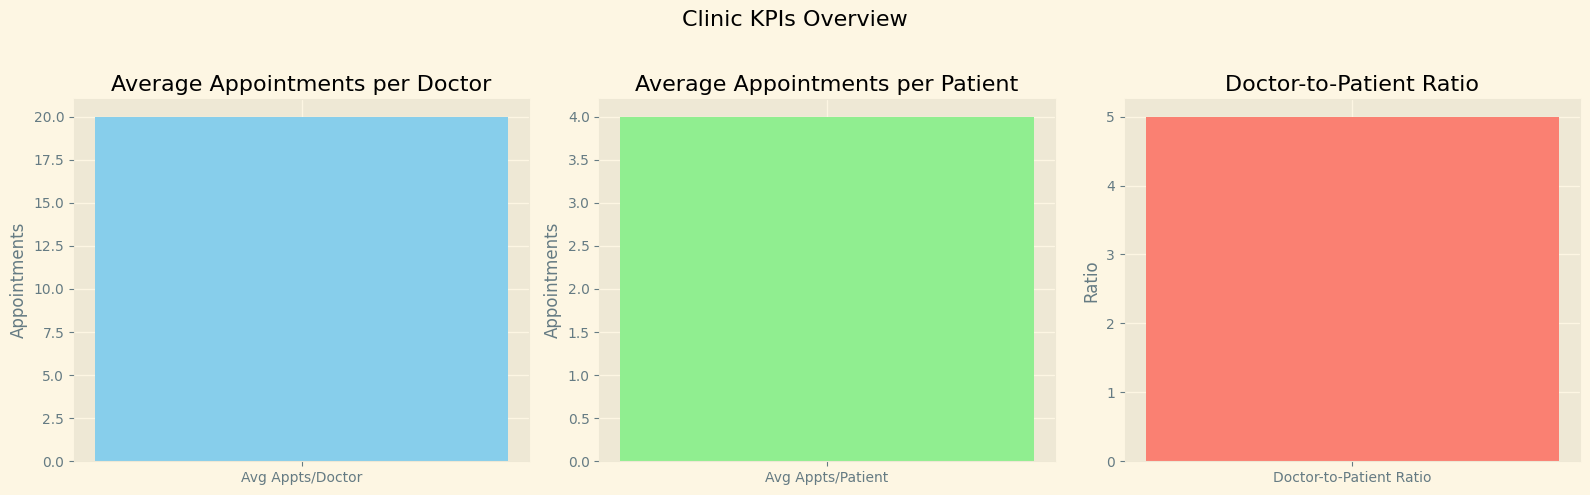


Analysis:
- Each doctor handles approximately 20.00 appointments on average, indicating workload distribution.
- Each patient visits the clinic about 4.00 times on average, showing patient engagement and follow-up frequency.
- The doctor-to-patient ratio of 5.00 provides insight into staffing adequacy relative to patient volume.


In [12]:
# =========================
# 4️⃣ Key Performance Indicators (KPIs) with Visualization
# =========================

# Average appointments per doctor
avg_appts_per_doctor = total_appointments / total_doctors

# Average appointments per patient
avg_appts_per_patient = total_appointments / total_patients

# Doctor-to-patient ratio
doctor_to_patient_ratio = total_patients / total_doctors

# Print KPIs
print(f"Average appointments per doctor: {avg_appts_per_doctor:.2f}")
print(f"Average appointments per patient: {avg_appts_per_patient:.2f}")
print(f"Doctor-to-patient ratio: {doctor_to_patient_ratio:.2f}")

# -------------------------
# Visualization
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(16,5))

# 1️⃣ Average appointments per doctor
axes[0].bar(['Avg Appts/Doctor'], [avg_appts_per_doctor], color='skyblue')
axes[0].set_ylabel('Appointments')
axes[0].set_title('Average Appointments per Doctor')

# 2️⃣ Average appointments per patient
axes[1].bar(['Avg Appts/Patient'], [avg_appts_per_patient], color='lightgreen')
axes[1].set_ylabel('Appointments')
axes[1].set_title('Average Appointments per Patient')

# 3️⃣ Doctor-to-patient ratio
axes[2].bar(['Doctor-to-Patient Ratio'], [doctor_to_patient_ratio], color='salmon')
axes[2].set_ylabel('Ratio')
axes[2].set_title('Doctor-to-Patient Ratio')

plt.suptitle('Clinic KPIs Overview', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# -------------------------
# KPI Analysis
# -------------------------
print("\nAnalysis:")
print(f"- Each doctor handles approximately {avg_appts_per_doctor:.2f} appointments on average, indicating workload distribution.")
print(f"- Each patient visits the clinic about {avg_appts_per_patient:.2f} times on average, showing patient engagement and follow-up frequency.")
print(f"- The doctor-to-patient ratio of {doctor_to_patient_ratio:.2f} provides insight into staffing adequacy relative to patient volume.")


In [13]:
# 4️⃣ Identify Top 5 Doctors by Number of Appointments
# ==========================================
query_top_doctors = """
SELECT 
    doctors.first_name || ' ' || doctors.last_name AS doctor_name,
    COUNT(appointments.appointment_id) AS total_appointments
FROM doctors
LEFT JOIN appointments ON doctors.doctor_id = appointments.doctor_id
GROUP BY doctors.doctor_id
ORDER BY total_appointments DESC
LIMIT 5;
"""

# Execute query and load into DataFrame
df_top_doctors = pd.read_sql(query_top_doctors, con=engine)
print("✅ Top 5 Doctors by Appointment Count:")
print(df_top_doctors)

# 4️⃣a Quick Analysis
print("\nAnalysis of Top 5 Doctors:")
for i, row in df_top_doctors.iterrows():
    print(f"{row['doctor_name']} handled {row['total_appointments']} appointments.")


✅ Top 5 Doctors by Appointment Count:
    doctor_name  total_appointments
0  Sarah Taylor                  29
1  David Taylor                  25
2    Alex Davis                  24
3    Jane Smith                  22
4    Jane Davis                  21

Analysis of Top 5 Doctors:
Sarah Taylor handled 29 appointments.
David Taylor handled 25 appointments.
Alex Davis handled 24 appointments.
Jane Smith handled 22 appointments.
Jane Davis handled 21 appointments.


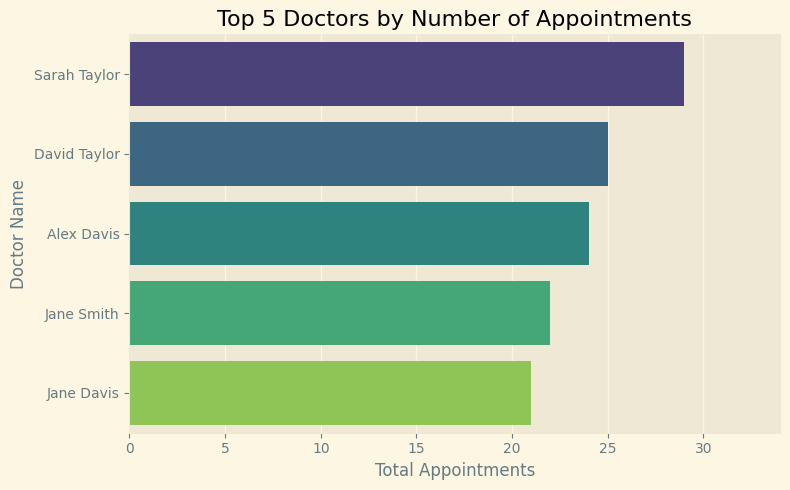

In [14]:
# 5️⃣ Visualization: Top 5 Doctors by Number of Appointments
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(
    x='total_appointments', 
    y='doctor_name', 
    data=df_top_doctors, 
    palette='viridis'
)
plt.title('Top 5 Doctors by Number of Appointments')
plt.xlabel('Total Appointments')
plt.ylabel('Doctor Name')
plt.xlim(0, max(df_top_doctors['total_appointments']) + 5)  # Add margin for readability
plt.tight_layout()

# Save the figure
plt.savefig("images/doctorsbyapp.png", dpi=300)

# Display the plot
plt.show()


**Analysis:**  

*Appointment counts vary noticeably among physicians. Sarah Taylor leads with 29 appointments, followed by David Taylor (25), Alex Davis (24), Jane Smith (22), and Jane Davis (21). The spread indicates higher patient demand for certain doctors, which may reflect specialization, availability, or patient preference patterns.*

  treatment_type  total_treatments
0   Chemotherapy                49
1          X-Ray                41
2            ECG                38
3  Physiotherapy                36
4            MRI                36


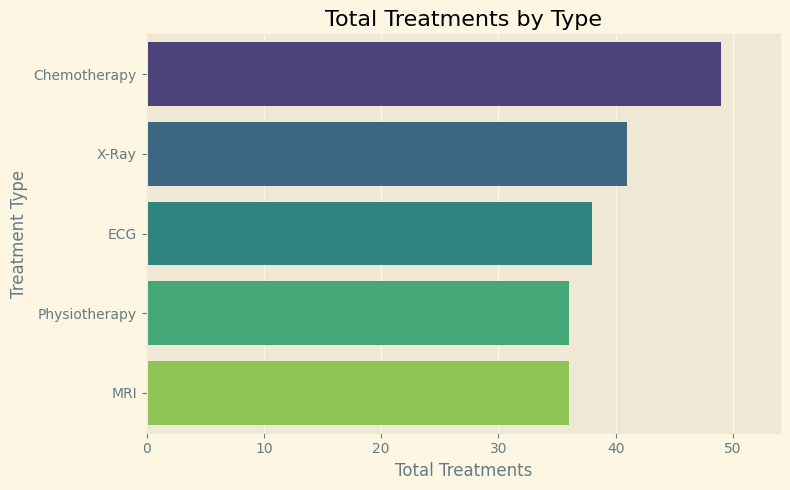

In [15]:
# Step 5: Treatments Analysis by Type
query_treatments = """
SELECT treatment_type, COUNT(*) AS total_treatments
FROM treatments
GROUP BY treatment_type
ORDER BY total_treatments DESC;
"""
df_treatments_by_type = pd.read_sql(query_treatments, con=engine)
print(df_treatments_by_type)

# Visualization
plt.figure(figsize=(8,5))
sns.barplot(x='total_treatments', y='treatment_type', data=df_treatments_by_type, palette='viridis')
plt.title('Total Treatments by Type')
plt.xlabel('Total Treatments')
plt.ylabel('Treatment Type')
plt.xlim(0, max(df_treatments_by_type['total_treatments']) + 5)
plt.tight_layout()
plt.savefig("images/totaltreatmentsbytype.png", dpi=300)
plt.show()


**Analysis:**  
*Chemotherapy is the most frequently administered treatment with 49 cases, followed by X-Ray (41), ECG (38), Physiotherapy (36), and MRI (36). The distribution shows a mix of diagnostic and long-term care procedures, indicating both ongoing management of chronic conditions and routine diagnostic workflows.*


  payment_status  total_amount
0         Failed     193212.94
1        Pending     184612.01
2           Paid     173424.90


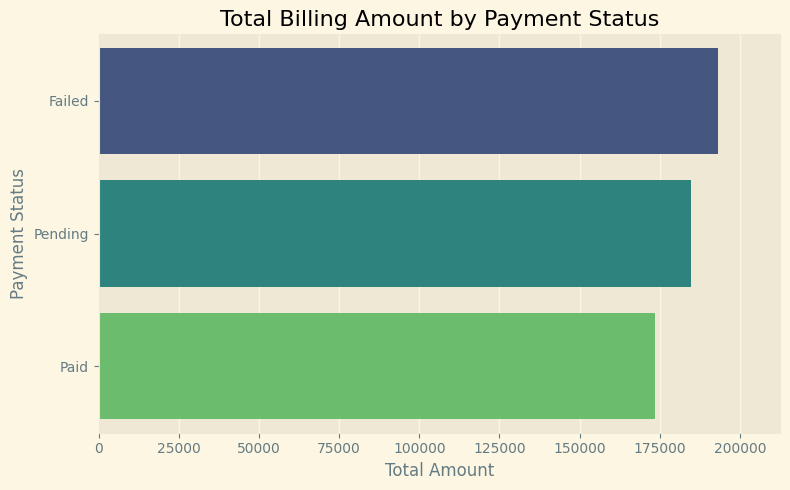

In [16]:
# Step 6: Billing Analysis by Payment Status
query_billing = """
SELECT payment_status, SUM(amount) AS total_amount
FROM billing
GROUP BY payment_status
ORDER BY total_amount DESC;
"""
df_billing_by_status = pd.read_sql(query_billing, con=engine)
print(df_billing_by_status)

# Visualization
plt.figure(figsize=(8,5))
sns.barplot(x='total_amount', y='payment_status', data=df_billing_by_status, palette='viridis')
plt.title('Total Billing Amount by Payment Status')
plt.xlabel('Total Amount')
plt.ylabel('Payment Status')
plt.xlim(0, max(df_billing_by_status['total_amount']) * 1.1)
plt.tight_layout()
plt.show()


**Analysis:**  

*Billing records show a clear imbalance across payment statuses: failed payments reach 193,212.94, pending payments total 184,612.01, and completed payments amount to 173,424.90. The size of the outstanding amounts suggests that the clinic operates with a sizable portion of uncollected revenue, which may affect liquidity and should prompt a review of follow-up procedures and payment workflows.*


  treatment_type  avg_cost
0            MRI   3224.95
1  Physiotherapy   2761.61
2          X-Ray   2698.87
3   Chemotherapy   2629.71
4            ECG   2532.22


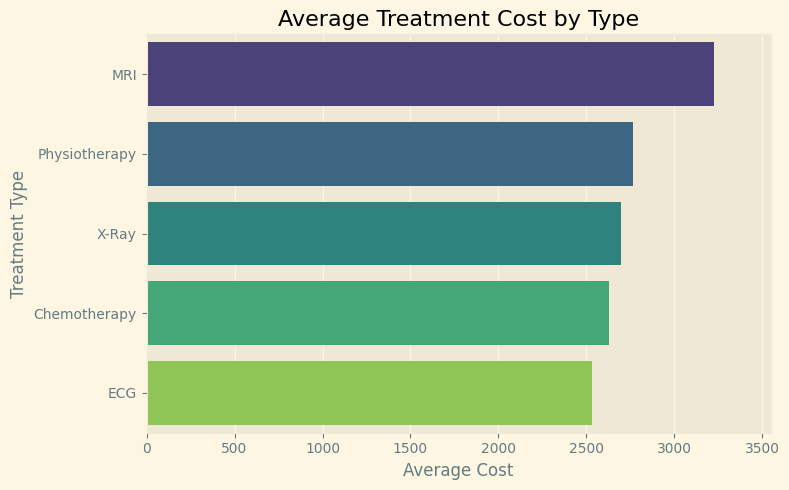

In [17]:
# Step 7: Average Treatment Cost by Type
query_avg_treatment_cost = """
SELECT treatment_type, AVG(cost) AS avg_cost
FROM treatments
GROUP BY treatment_type
ORDER BY avg_cost DESC;
"""
df_avg_cost_by_treatment = pd.read_sql(query_avg_treatment_cost, con=engine)
print(df_avg_cost_by_treatment)

# Visualization
plt.figure(figsize=(8,5))
sns.barplot(x='avg_cost', y='treatment_type', data=df_avg_cost_by_treatment, palette='viridis')
plt.title('Average Treatment Cost by Type')
plt.xlabel('Average Cost')
plt.ylabel('Treatment Type')
plt.xlim(0, max(df_avg_cost_by_treatment['avg_cost']) * 1.1)
plt.tight_layout()
plt.savefig("images/avg_treatment_cost_by_type.png", dpi=300)
plt.show()


**Analysis:**  

*MRI has the highest average cost at 3,224.95, followed by Physiotherapy at 2,761.61, X-Ray at 2,698.87, Chemotherapy at 2,629.71, and ECG at 2,532.22. The spread indicates meaningful variation in procedure pricing, with imaging-based services generally sitting at the upper end. These differences reflect resource intensity and can inform decisions around pricing updates or cost-control efforts.*

  treatment_type  total_revenue
0   Chemotherapy      128855.68
1            MRI      116098.16
2          X-Ray      110653.67
3  Physiotherapy       99418.10
4            ECG       96224.24


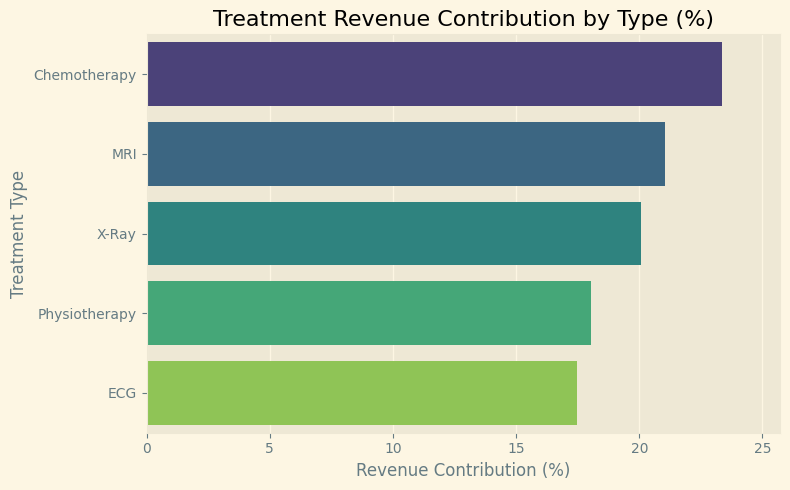

In [18]:
# Step 8: Treatment Revenue Contribution by Type
query_revenue_contribution = """
SELECT treatment_type, SUM(cost) AS total_revenue
FROM treatments
GROUP BY treatment_type
ORDER BY total_revenue DESC;
"""
df_revenue_by_treatment = pd.read_sql(query_revenue_contribution, con=engine)
print(df_revenue_by_treatment)

# Calculate percentage contribution of each treatment type
df_revenue_by_treatment['percentage'] = (df_revenue_by_treatment['total_revenue'] / 
                                         df_revenue_by_treatment['total_revenue'].sum()) * 100

# Visualization
plt.figure(figsize=(8,5))
sns.barplot(x='percentage', y='treatment_type', data=df_revenue_by_treatment, palette='viridis')
plt.title('Treatment Revenue Contribution by Type (%)')
plt.xlabel('Revenue Contribution (%)')
plt.ylabel('Treatment Type')
plt.xlim(0, df_revenue_by_treatment['percentage'].max() * 1.1)
plt.tight_layout()
plt.savefig("images/treatment_revenue_contribution.png", dpi=300)
plt.show()


      month  total_appointments  total_revenue
0   2023-01                  20       58701.23
1   2023-02                  14       36669.69
2   2023-03                  19       47304.29
3   2023-04                  25       64271.54
4   2023-05                  19       48791.05
5   2023-06                  18       56887.82
6   2023-07                  16       39880.19
7   2023-08                  15       41958.67
8   2023-09                  11       33426.53
9   2023-10                  14       43314.15
10  2023-11                  17       52474.98
11  2023-12                  12       27569.71


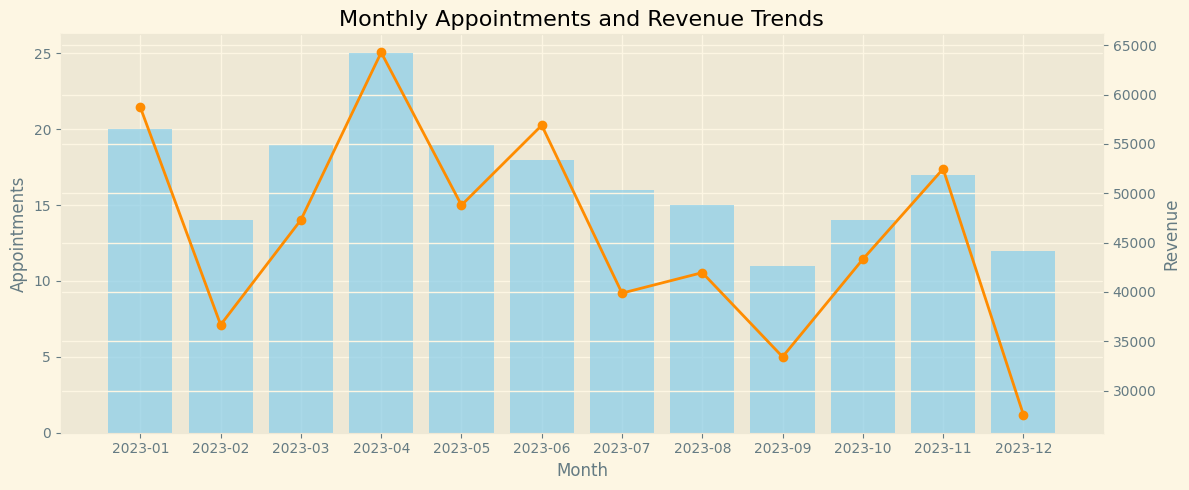

In [19]:
# Step 9: Monthly Appointments and Revenue Trends
query_monthly_trends = """
SELECT 
    strftime('%Y-%m', a.appointment_date) AS month,
    COUNT(a.appointment_id) AS total_appointments,
    SUM(b.amount) AS total_revenue
FROM appointments a
LEFT JOIN treatments t ON a.appointment_id = t.appointment_id
LEFT JOIN billing b ON t.treatment_id = b.treatment_id
GROUP BY month
ORDER BY month;
"""
df_monthly_trends = pd.read_sql(query_monthly_trends, con=engine)
print(df_monthly_trends)

# Visualization
fig, ax1 = plt.subplots(figsize=(12,5))

# Bar chart: total appointments per month
ax1.bar(
    df_monthly_trends['month'],
    df_monthly_trends['total_appointments'],
    color='skyblue',
    alpha=0.7,
    label='Appointments'
)
ax1.set_xlabel('Month')
ax1.set_ylabel('Appointments')
ax1.tick_params(axis='y')

# Line chart: revenue per month (secondary y-axis)
ax2 = ax1.twinx()
ax2.plot(
    df_monthly_trends['month'],
    df_monthly_trends['total_revenue'],
    color='darkorange',
    marker='o',
    linewidth=2,
    label='Revenue'
)
ax2.set_ylabel('Revenue')
ax2.tick_params(axis='y')

plt.title('Monthly Appointments and Revenue Trends')
plt.xticks(rotation=45)
fig.tight_layout()

# Save figure
plt.savefig("images/monthly_appointments_revenue_trends.png", dpi=300)
plt.show()


      month  total_appointments
0   2023-01                  20
1   2023-02                  14
2   2023-03                  19
3   2023-04                  25
4   2023-05                  19
5   2023-06                  18
6   2023-07                  16
7   2023-08                  15
8   2023-09                  11
9   2023-10                  14
10  2023-11                  17
11  2023-12                  12


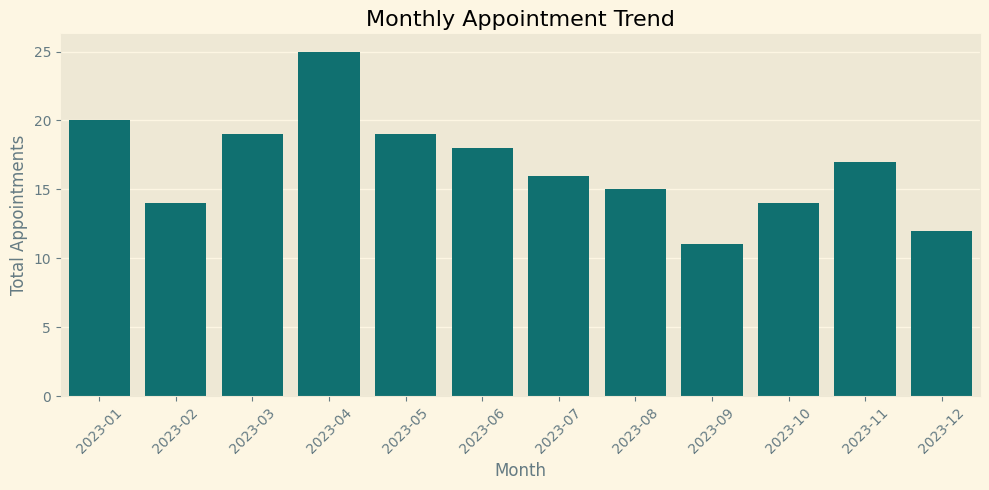

In [20]:
# Step 10: Monthly Appointment Trend
query_monthly_appointments = """
SELECT 
    strftime('%Y-%m', appointment_date) AS month,
    COUNT(appointment_id) AS total_appointments
FROM appointments
GROUP BY month
ORDER BY month;
"""
df_monthly_appointments = pd.read_sql(query_monthly_appointments, con=engine)
print(df_monthly_appointments)

# Visualization - Bar Plot
plt.figure(figsize=(10,5))
sns.barplot(data=df_monthly_appointments, x='month', y='total_appointments', color='teal')
plt.title('Monthly Appointment Trend')
plt.xlabel('Month')
plt.ylabel('Total Appointments')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/appointments_trend.png", dpi=300)
plt.show()


**Analysis:**  

*Monthly data for 2023 shows fluctuations in both appointments and revenue. Activity rises in April with 25 appointments generating 64,271.54, while other months range between 11 and 20 appointments. Revenue follows a similar pattern, peaking in high-volume months and easing during quieter periods. These oscillations provide a realistic picture of demand cycles that influence staffing, operating hours, and financial forecasting.*

  gender  total
0      F     19
1      M     31


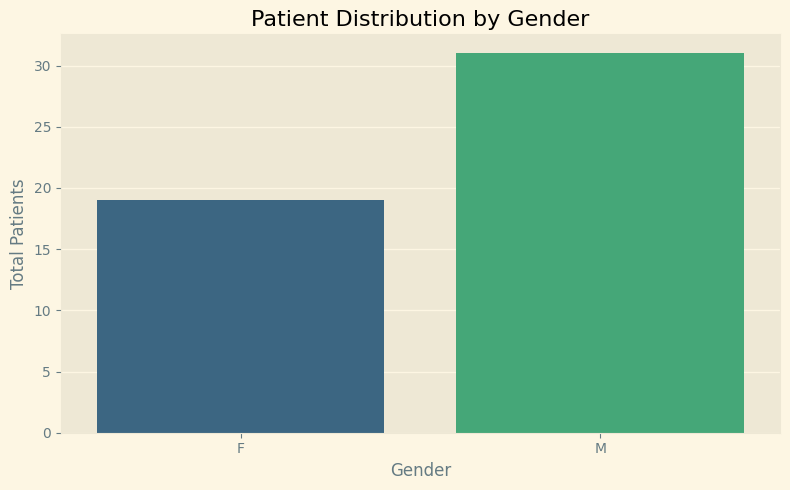

In [21]:
# Step 11: Gender Distribution of Patients
query_gender_distribution = """
SELECT 
    gender, 
    COUNT(*) AS total
FROM patients
GROUP BY gender;
"""
df_gender = pd.read_sql(query_gender_distribution, con=engine)
print(df_gender)

# Visualization - Bar Plot
plt.figure(figsize=(8,5))
sns.barplot(data=df_gender, x='gender', y='total', palette='viridis')
plt.title("Patient Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Patients")
plt.tight_layout()
plt.savefig("images/gender_distribution.png", dpi=300)
plt.show()


**Analysis:**  
*The patient population consists of 31 males and 19 females. This skew toward male patients may shape service demand, particularly in areas where health-seeking behavior or condition prevalence differs by gender. The clinic can factor this distribution into program design and outreach strategies.*


   avg_age
0    45.40


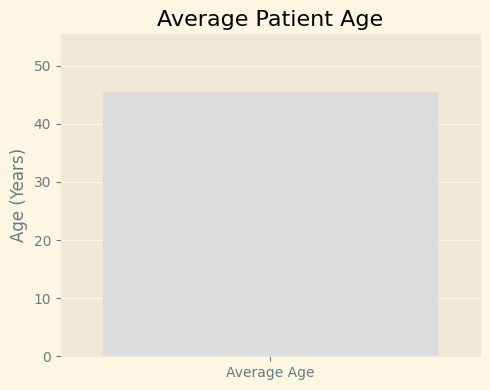

In [22]:
# Step 12: Average Patient Age
query_avg_age = """
SELECT 
    ROUND(AVG((julianday('now') - julianday(date_of_birth)) / 365.25), 1) AS avg_age
FROM patients;
"""
df_avg_age = pd.read_sql(query_avg_age, con=engine)
print(df_avg_age)

# Optional Visualization
plt.figure(figsize=(5,4))
sns.barplot(x=['Average Age'], y=df_avg_age['avg_age'], palette='coolwarm')
plt.title("Average Patient Age")
plt.ylabel("Age (Years)")
plt.ylim(0, df_avg_age['avg_age'][0] + 10)
plt.tight_layout()
plt.savefig("images/average_patient_age.png", dpi=300)
plt.show()


**Analysis:**  
*The average patient age is 45.40 years, pointing to a primarily middle-aged clientele. This demographic typically requires a mix of chronic-disease management, routine diagnostics, and preventive care, which can help guide service prioritization and resource planning.*


  insurance_provider  total_patients
0       MedCare Plus              18
1       WellnessCorp              16
2        PulseSecure              10
3        HealthIndia               6


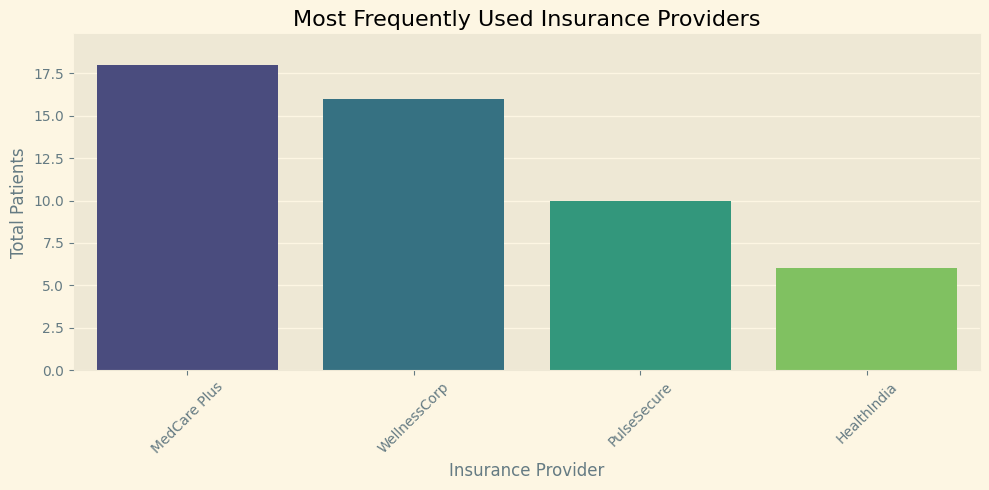

In [23]:
# ============================================
# Insurance Providers Usage - Unified Format
# ============================================

# Query
query_insurance_usage = """
SELECT 
    insurance_provider, 
    COUNT(*) AS total_patients
FROM patients
GROUP BY insurance_provider
ORDER BY total_patients DESC;
"""

df_insurance = pd.read_sql(query_insurance_usage, con=engine)
print(df_insurance)

# Visualization (Unified)
plt.figure(figsize=(10,5))
sns.barplot(data=df_insurance, x='insurance_provider', y='total_patients', palette='viridis')
plt.title("Most Frequently Used Insurance Providers")
plt.xlabel("Insurance Provider")
plt.ylabel("Total Patients")
plt.xticks(rotation=45)
plt.ylim(0, df_insurance['total_patients'].max() * 1.1)  # dynamic upper limit
plt.tight_layout()
plt.savefig("images/insurance_provider_breakdown.png", dpi=300)
plt.show()


**Analysis:**  
*Insurance usage is concentrated among a few providers: MedCare Plus covers 18 patients, WellnessCorp 16, PulseSecure 10, and HealthIndia 6. This distribution indicates where administrative coordination is most frequent and can influence negotiations, claim-handling strategies, and partnership development.*

In [24]:
# ============================================
# Retrieve All Doctors - Unified Format
# ============================================

# Query
query_all_doctors = """
SELECT *
FROM doctors;
"""

df_doctors = pd.read_sql(query_all_doctors, con=engine)
print(df_doctors)


  doctor_id first_name last_name specialization  phone_number  \
0      D001      David    Taylor    Dermatology    8322010158   
1      D002       Jane     Davis     Pediatrics    9004382050   
2      D003       Jane     Smith     Pediatrics    8737740598   
3      D004      David     Jones     Pediatrics    6594221991   
4      D005      Sarah    Taylor    Dermatology    9118538547   
5      D006       Alex     Davis     Pediatrics    6570137231   
6      D007     Robert     Davis       Oncology    8217493115   
7      D008      Linda     Brown    Dermatology    9069162601   
8      D009      Sarah     Smith     Pediatrics    7387087517   
9      D010      Linda    Wilson       Oncology    6176383634   

   years_experience   hospital_branch                         email  
0                17   Westside Clinic  dr.david.taylor@hospital.com  
1                24   Eastside Clinic    dr.jane.davis@hospital.com  
2                19   Eastside Clinic    dr.jane.smith@hospital.com  
3   

  specialization  total_doctors
0     Pediatrics              5
1    Dermatology              3
2       Oncology              2


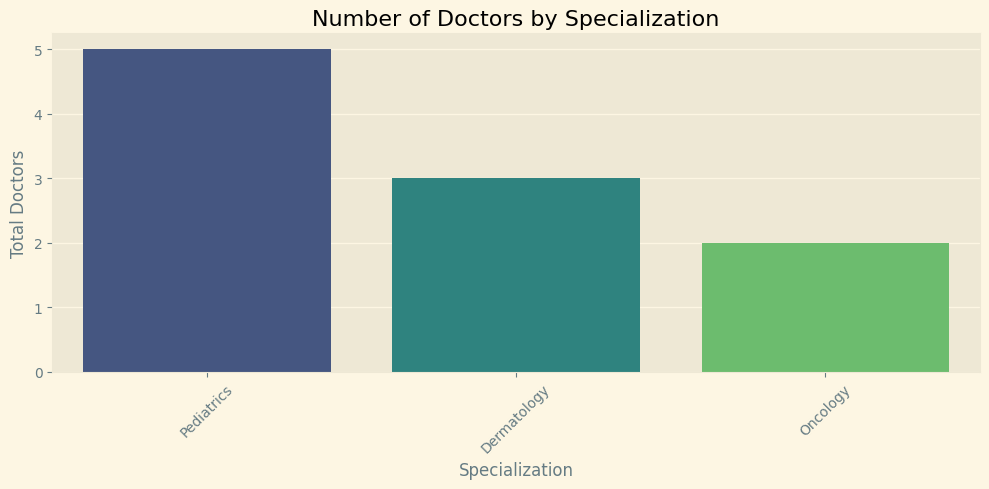

In [25]:
# ============================================
# Doctors by Specialization - Unified Format
# ============================================

# Query
query_doctors_by_specialization = """
SELECT 
    specialization, 
    COUNT(*) AS total_doctors
FROM doctors
GROUP BY specialization
ORDER BY total_doctors DESC;
"""

df_specialization = pd.read_sql(query_doctors_by_specialization, con=engine)
print(df_specialization)

# Visualization (Unified)
plt.figure(figsize=(10,5))
sns.barplot(data=df_specialization, x='specialization', y='total_doctors', palette='viridis')
plt.title("Number of Doctors by Specialization")
plt.xlabel("Specialization")
plt.ylabel("Total Doctors")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Analysis:**  
*Pediatrics is the largest specialization with 5 doctors, followed by Dermatology with 3 and Oncology with 2. This staffing pattern suggests strong pediatric coverage, moderate dermatology capacity, and a smaller oncology presence. The mix could guide decisions about service expansion or alignment with patient demand trends.*


  specialization  total_revenue
0     Pediatrics      258937.83
1    Dermatology      202709.29
2       Oncology       89602.73


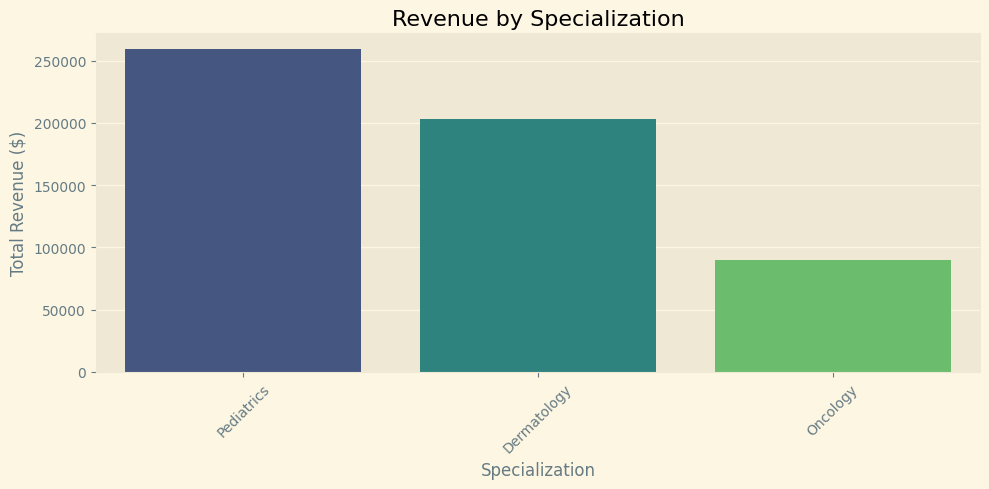

In [26]:
# ============================================
# Specialization Revenue Analysis - Unified Format
# ============================================

# Query
query_specialization_revenue = """
SELECT 
    d.specialization,
    SUM(b.amount) AS total_revenue
FROM billing b
JOIN treatments t ON b.treatment_id = t.treatment_id
JOIN appointments a ON t.appointment_id = a.appointment_id
JOIN doctors d ON a.doctor_id = d.doctor_id
GROUP BY d.specialization
ORDER BY total_revenue DESC;
"""

df_specialization_revenue = pd.read_sql(query_specialization_revenue, con=engine)
print(df_specialization_revenue)

# Visualization - Bar Plot
plt.figure(figsize=(10,5))
sns.barplot(
    data=df_specialization_revenue,
    x='specialization',
    y='total_revenue',
    palette='viridis'
)
plt.title('Revenue by Specialization')
plt.xlabel('Specialization')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/specialization_revenue.png", dpi=300)
plt.show()


    hospital_branch  avg_exp
0  Central Hospital    25.80
1   Eastside Clinic    21.30
2   Westside Clinic    16.00


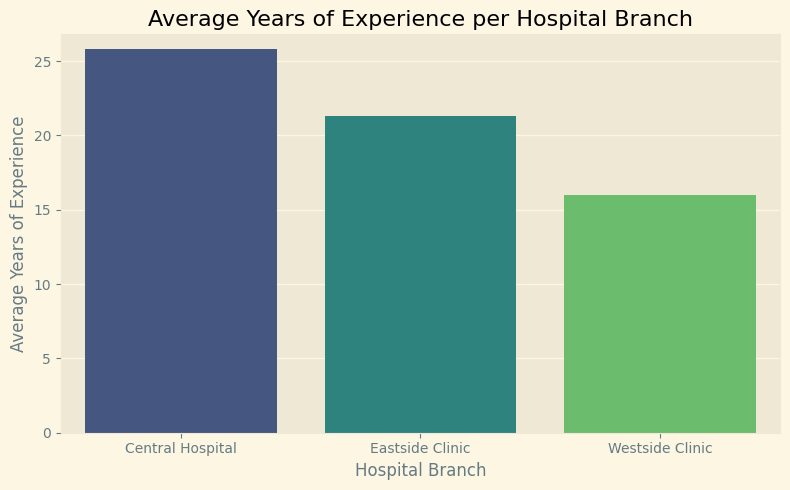

In [27]:
# ============================================
# Step 14: Average Years of Experience per Hospital Branch - Unified Format
# ============================================

# Query
query_avg_exp = """
SELECT hospital_branch, ROUND(AVG(years_experience), 1) AS avg_exp
FROM doctors
GROUP BY hospital_branch
ORDER BY avg_exp DESC;
"""

df_avg_exp = pd.read_sql(query_avg_exp, con=engine)
print(df_avg_exp)

# Visualization - Bar Plot
plt.figure(figsize=(8,5))
sns.barplot(data=df_avg_exp, x='hospital_branch', y='avg_exp', palette='viridis')
plt.title('Average Years of Experience per Hospital Branch')
plt.xlabel('Hospital Branch')
plt.ylabel('Average Years of Experience')
plt.ylim(0, max(df_avg_exp['avg_exp']) + 1)
plt.tight_layout()
plt.savefig("images/doctor_experience_branch.png", dpi=300)
plt.show()


**Analysis:**  

*Average experience varies noticeably across branches: Central Hospital leads with 25.8 years, Eastside Clinic averages 21.3 years, and Westside Clinic 16.0 years. These differences can influence where complex cases are directed and where mentorship or training investments may be most effective.*


In [28]:
# ============================================
# Retrieve All Appointment Records - Unified Format
# ============================================

query_all_appointments = """SELECT * FROM appointments;"""
df_appointments = pd.read_sql(query_all_appointments, con=engine)
print(df_appointments)


    appointment_id patient_id doctor_id appointment_date appointment_time  \
0             A001       P034      D009       2023-08-09         15:15:00   
1             A002       P032      D004       2023-06-09         14:30:00   
2             A003       P048      D004       2023-06-28          8:00:00   
3             A004       P025      D006       2023-09-01          9:15:00   
4             A005       P040      D003       2023-07-06         12:45:00   
..             ...        ...       ...              ...              ...   
195           A196       P045      D006       2023-10-26          9:45:00   
196           A197       P001      D005       2023-04-01         13:30:00   
197           A198       P022      D006       2023-05-15          8:30:00   
198           A199       P017      D001       2023-05-01         12:45:00   
199           A200       P007      D005       2023-12-30         10:15:00   

    reason_for_visit     status  
0            Therapy  Scheduled  
1      

      status  total
0    No-show     52
1  Scheduled     51
2  Cancelled     51
3  Completed     46


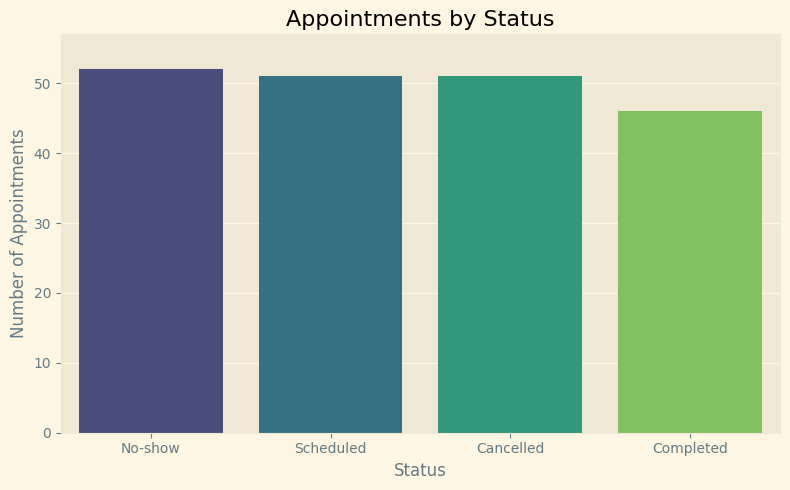

In [29]:
# ============================================
# Step 15: Appointments by Status - Unified Format
# ============================================

# Query
query_appointments_status = """
SELECT status, COUNT(*) AS total
FROM appointments
GROUP BY status
ORDER BY total DESC;
"""
df_appointments_status = pd.read_sql(query_appointments_status, con=engine)
print(df_appointments_status)

# Unified Visualization
plt.figure(figsize=(8,5))
sns.barplot(data=df_appointments_status, x='status', y='total', palette='viridis')
plt.title('Appointments by Status')
plt.xlabel('Status')
plt.ylabel('Number of Appointments')
plt.ylim(0, max(df_appointments_status['total']) + 5)
plt.tight_layout()
plt.savefig("images/appointments_by_status.png", dpi=300)
plt.show()


**Analysis:**  
*Appointment statuses show a near-even split among categories, with no-shows being slightly higher at 52 cases. Scheduled and cancelled appointments both number 51, while 46 are completed. The high rate of incomplete visits points to opportunities to tighten reminder systems, scheduling processes, and patient follow-through.*


  reason_for_visit  total
0          Checkup     45
1     Consultation     43
2          Therapy     42
3        Follow-up     41
4        Emergency     29


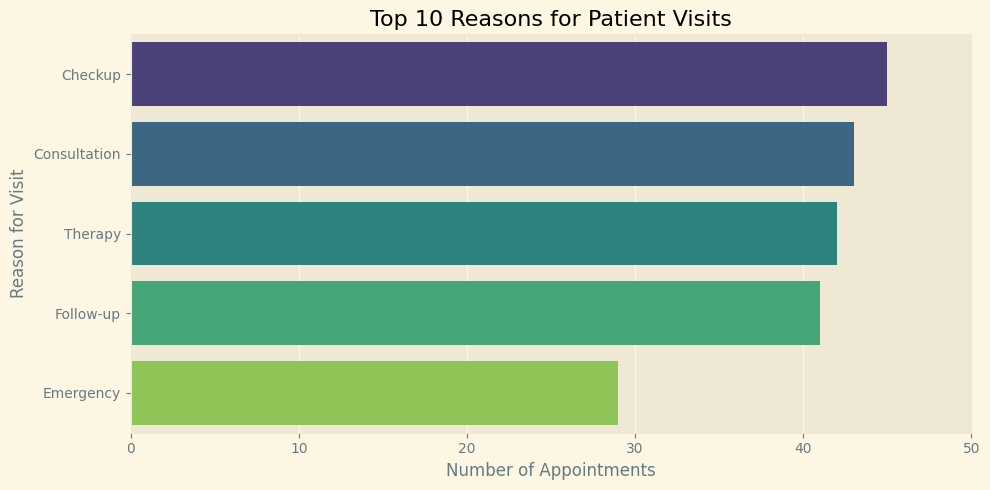

In [30]:
# ============================================
# Step 16: Most Common Reasons for Visit - Unified Format
# ============================================

# Query
query_visit_reasons = """
SELECT reason_for_visit, COUNT(*) AS total
FROM appointments
GROUP BY reason_for_visit
ORDER BY total DESC
LIMIT 10;
"""
df_visit_reasons = pd.read_sql(query_visit_reasons, con=engine)
print(df_visit_reasons)

# Unified Visualization
plt.figure(figsize=(10,5))
sns.barplot(data=df_visit_reasons, y='reason_for_visit', x='total', palette='viridis')
plt.title('Top 10 Reasons for Patient Visits')
plt.xlabel('Number of Appointments')
plt.ylabel('Reason for Visit')
plt.xlim(0, max(df_visit_reasons['total']) + 5)
plt.tight_layout()
plt.savefig("images/appointment_reasons.png", dpi=300)
plt.show()


**Analysis:**  

*Checkups are the most common visit reason with 45 cases, closely followed by Consultations (43), Therapy sessions (42), and Follow-ups (41). Emergency visits are noticeably lower at 29. The pattern reflects a clinic environment driven by routine and ongoing care rather than acute or unplanned visits.*


In [31]:
# ============================================
# Step 17: Retrieve All Treatment Records - Unified Format
# ============================================

# Query
query_all_treatments = """SELECT * FROM treatments;"""
df_all_treatments = pd.read_sql(query_all_treatments, con=engine)
print(df_all_treatments)


    treatment_id appointment_id treatment_type         description    cost  \
0           T001           A001   Chemotherapy     Basic screening 3941.97   
1           T002           A002            MRI   Advanced protocol 4158.44   
2           T003           A003            MRI  Standard procedure 3731.55   
3           T004           A004            MRI     Basic screening 4799.86   
4           T005           A005            ECG  Standard procedure  582.05   
..           ...            ...            ...                 ...     ...   
195         T196           A196   Chemotherapy   Advanced protocol 2477.80   
196         T197           A197  Physiotherapy  Standard procedure  975.49   
197         T198           A198            ECG     Basic screening 3383.72   
198         T199           A199   Chemotherapy     Basic screening 1472.17   
199         T200           A200          X-Ray     Basic screening 3288.15   

    treatment_date  
0       2023-08-09  
1       2023-06-09  


  doctor_id first_name last_name  total_revenue
0      D005      Sarah    Taylor       82696.48
1      D006       Alex     Davis       69586.10
2      D001      David    Taylor       66585.39
3      D002       Jane     Davis       59803.46
4      D008      Linda     Brown       53427.42
5      D003       Jane     Smith       52791.41
6      D010      Linda    Wilson       49436.23
7      D007     Robert     Davis       40166.50
8      D004      David     Jones       39315.95
9      D009      Sarah     Smith       37440.91


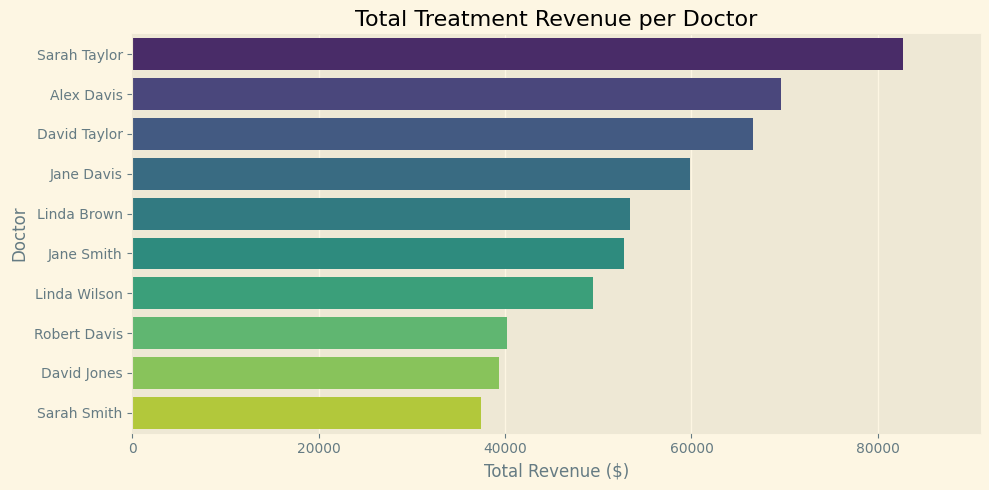

In [32]:
# ============================================
# Step 18: Total Treatment Revenue per Doctor - Unified Format
# ============================================

# Query
query_doctor_revenue = """
SELECT 
    d.doctor_id,
    d.first_name,
    d.last_name,
    SUM(b.amount) AS total_revenue
FROM billing b
JOIN treatments t ON b.treatment_id = t.treatment_id
JOIN appointments a ON t.appointment_id = a.appointment_id
JOIN doctors d ON a.doctor_id = d.doctor_id
GROUP BY d.doctor_id, d.first_name, d.last_name
ORDER BY total_revenue DESC;
"""
df_doctor_revenue = pd.read_sql(query_doctor_revenue, con=engine)
print(df_doctor_revenue)

# Unified Visualization
plt.figure(figsize=(10,5))
doctor_names = df_doctor_revenue['first_name'] + ' ' + df_doctor_revenue['last_name']
sns.barplot(data=df_doctor_revenue, y=doctor_names, x='total_revenue', palette='viridis')
plt.title('Total Treatment Revenue per Doctor')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Doctor')
plt.xlim(0, df_doctor_revenue['total_revenue'].max() * 1.1)
plt.tight_layout()
plt.savefig("images/doctor_total_revenue.png", dpi=300)
plt.show()


**Analysis:**  

*Treatment revenue varies significantly across physicians. Sarah Taylor generates the highest total at 82,696.48, with Alex Davis at 69,586.10 and David Taylor at 66,585.39. These differences likely reflect case mix, appointment volume, and treatment complexity, providing a useful reference for performance evaluation and service planning.*


In [33]:
# ============================================
# Step 19: Retrieve All Billing Records - Unified Format
# ============================================

# Query
query_billing_all = """SELECT * FROM billing;"""
df_billing_all = pd.read_sql(query_billing_all, con=engine)
print(df_billing_all)


    bill_id patient_id treatment_id   bill_date  amount payment_method  \
0      B001       P034         T001  2023-08-09 3941.97      Insurance   
1      B002       P032         T002  2023-06-09 4158.44      Insurance   
2      B003       P048         T003  2023-06-28 3731.55      Insurance   
3      B004       P025         T004  2023-09-01 4799.86      Insurance   
4      B005       P040         T005  2023-07-06  582.05    Credit Card   
..      ...        ...          ...         ...     ...            ...   
195    B196       P045         T196  2023-10-26 2477.80           Cash   
196    B197       P001         T197  2023-04-01  975.49           Cash   
197    B198       P022         T198  2023-05-15 3383.72           Cash   
198    B199       P017         T199  2023-05-01 1472.17    Credit Card   
199    B200       P007         T200  2023-12-30 3288.15      Insurance   

    payment_status  
0          Pending  
1             Paid  
2             Paid  
3           Failed  
4     

In [34]:
# ============================================
# Step 18: Total Revenue - Unified Format
# ============================================

# Query
query_total_revenue = """SELECT SUM(amount) AS total_revenue FROM billing;"""
df_total_revenue = pd.read_sql(query_total_revenue, con=engine)

# Extract value
total_revenue = df_total_revenue['total_revenue'][0]
print(f"Total Revenue: ${total_revenue:,.2f}")


Total Revenue: $551,249.85


**Analysis:**  

*Total revenue generated from treatments amounts to 551,249.85. This figure represents the clinic’s overall earning capacity from medical services and sets a reference point for evaluating profitability, cost structures, and future revenue targets.*


In [35]:
# ✅ Step: Overall Collection Rate
query_collection_rate = """
SELECT 
    SUM(CASE WHEN payment_status = 'Paid' THEN 1 ELSE 0 END) * 1.0 /
    COUNT(*) * 100 AS collection_rate
FROM billing;
"""
df_collection_rate = pd.read_sql(query_collection_rate, con=engine)
collection_rate = df_collection_rate['collection_rate'][0]
print(f"Overall Collection Rate: {collection_rate:.2f}%")


Overall Collection Rate: 32.00%


**Analysis.**

*The overall collection rate stands at 32%, indicating that less than one-third of billed amounts have been successfully collected. This low collection rate signals potential issues in billing follow-up, payment processing, or patient financial engagement. The clinic may need to prioritize overdue accounts, strengthen communication with patients regarding outstanding balances, and optimize payment methods. Improving this metric could directly increase cash flow and operational sustainability, highlighting the importance of targeted revenue cycle management and timely collections.*

  payment_method  total_revenue
0    Credit Card      201382.43
1      Insurance      182160.28
2           Cash      167707.14


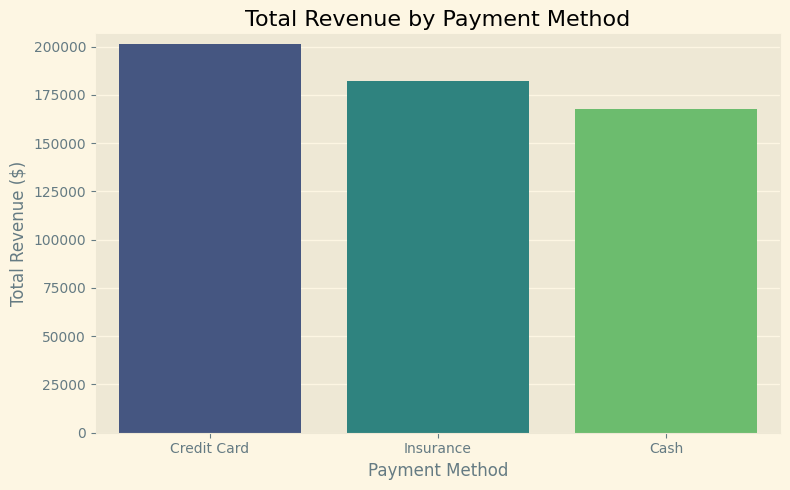

In [36]:
# ============================================
# Step 19: Revenue by Payment Method - Unified Format
# ============================================

# Query
query_revenue_by_method = """
SELECT payment_method, SUM(amount) AS total_revenue
FROM billing
GROUP BY payment_method
ORDER BY total_revenue DESC;
"""
df_revenue_by_method = pd.read_sql(query_revenue_by_method, con=engine)
print(df_revenue_by_method)

# Unified Visualization
plt.figure(figsize=(8,5))
sns.barplot(data=df_revenue_by_method, x='payment_method', y='total_revenue', palette='viridis')
plt.title('Total Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Revenue ($)')
plt.ylim(0, df_revenue_by_method['total_revenue'].max() + 5000)
plt.tight_layout()
plt.savefig("images/payment_method_breakdown.png", dpi=300)
plt.show()


**Analysis:**  

*Revenue distribution across payment methods shows Credit Card transactions leading at 201,382.43, followed by Insurance at 182,160.28 and Cash at 167,707.14. These differences highlight common payment preferences and point to where administrative or processing efficiencies may have the greatest impact.*


  payment_status  total  percentage
0         Failed     67       33.50
1           Paid     64       32.00
2        Pending     69       34.50


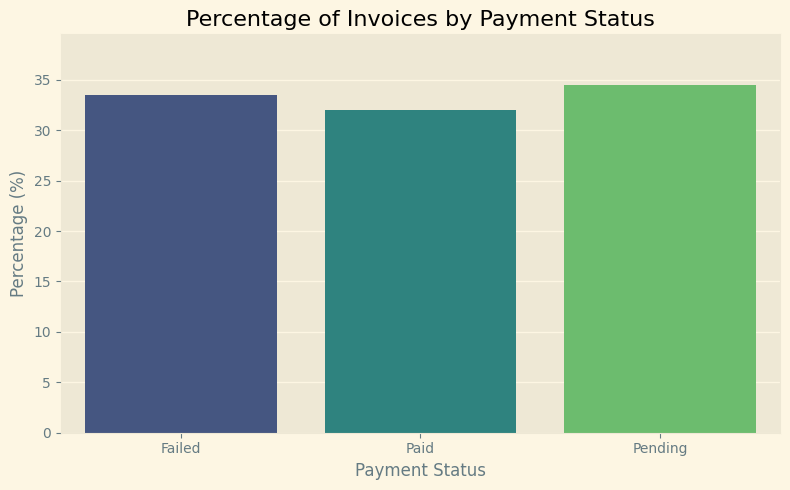

In [37]:
# ============================================
# Step 20: Percentage of Invoices by Payment Status - Unified Format
# ============================================

# Query
query_payment_status_pct = """
SELECT 
    payment_status,
    COUNT(*) AS total,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM billing), 1) AS percentage
FROM billing
GROUP BY payment_status;
"""
df_payment_status_pct = pd.read_sql(query_payment_status_pct, con=engine)
print(df_payment_status_pct)

# Unified Visualization
plt.figure(figsize=(8,5))
sns.barplot(data=df_payment_status_pct, x='payment_status', y='percentage', palette='viridis')
plt.title('Percentage of Invoices by Payment Status')
plt.xlabel('Payment Status')
plt.ylabel('Percentage (%)')
plt.ylim(0, df_payment_status_pct['percentage'].max() + 5)
plt.tight_layout()
plt.savefig("images/collection_rate_trend.png", dpi=300)
plt.show()


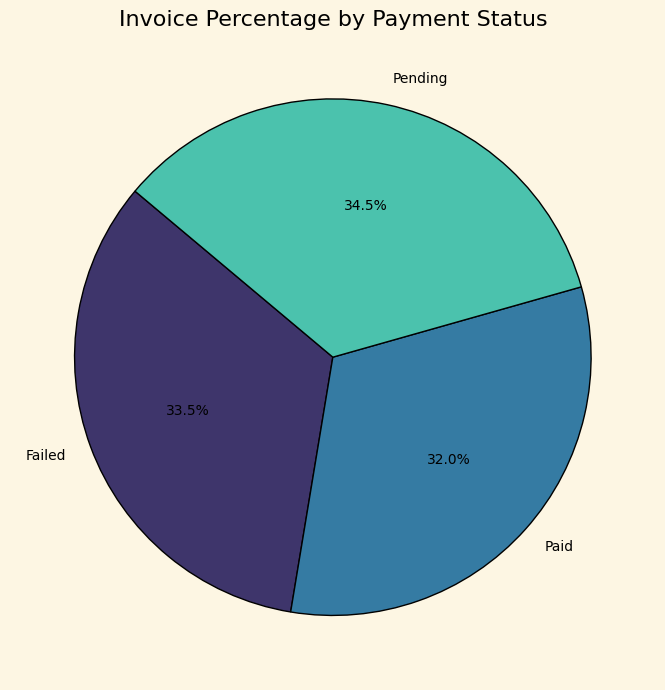

In [38]:
# ============================================
# Step 21: Pie Chart for Payment Status Percentage - Unified Format
# ============================================

plt.figure(figsize=(7,7))

# Color palette consistent with other visuals
colors = sns.color_palette("mako", len(df_payment_status_pct))

plt.pie(
    df_payment_status_pct['percentage'], 
    labels=df_payment_status_pct['payment_status'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    wedgeprops={'edgecolor':'black'}
)

plt.title('Invoice Percentage by Payment Status')
plt.tight_layout()
plt.savefig("images/payment_status_pie.png", dpi=300)
plt.show()


**Analysis:**  

*Pending invoices account for 34 percent of all records, closely followed by failed payments at 33 percent and completed payments at 32 percent. The near-equal distribution, combined with the high share of non-completed invoices, signals pressure on cash flow and the need for stronger follow-up and payment assurance mechanisms.*

      month  total_revenue
0   2023-01       58701.23
1   2023-02       36669.69
2   2023-03       47304.29
3   2023-04       64271.54
4   2023-05       48791.05
5   2023-06       56887.82
6   2023-07       39880.19
7   2023-08       41958.67
8   2023-09       33426.53
9   2023-10       43314.15
10  2023-11       52474.98
11  2023-12       27569.71


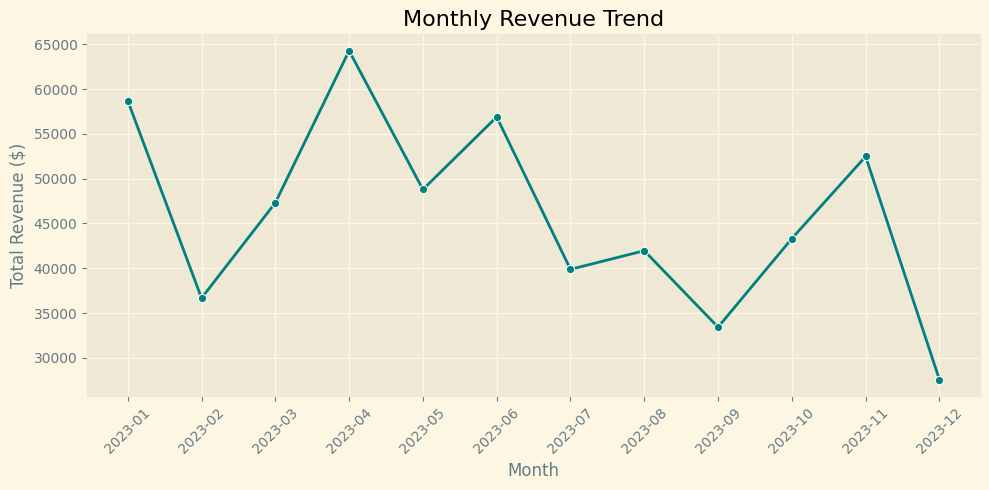

In [39]:
# ============================================
# Step 22: Monthly Revenue Trend - Unified Format
# ============================================

query_monthly_revenue = """
SELECT 
    strftime('%Y-%m', bill_date) AS month, 
    SUM(amount) AS total_revenue
FROM billing
GROUP BY month
ORDER BY month;
"""

df_monthly_revenue = pd.read_sql(query_monthly_revenue, con=engine)
print(df_monthly_revenue)

# Unified Visualization
plt.figure(figsize=(10,5))
sns.lineplot(
    data=df_monthly_revenue, 
    x='month', 
    y='total_revenue', 
    marker='o', 
    color='teal'
)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/monthly_revenue_trend.png", dpi=300)
plt.show()


**Analysis:**  

*Revenue peaks in April at 64,271.54 and falls to its lowest point in December at 27,569.71. January and June also show relatively strong performance, at 58,701.23 and 56,888.00 respectively. The pattern reflects noticeable seasonality in earnings that should be incorporated into annual budgeting and staffing decisions.*

*The sharp decline in December revenue to 27,569.71 stands out as the most significant downturn of the year. Unlike other low months such as September, the December drop is steeper and more abrupt, indicating heightened end-of-year volatility that may require targeted mitigation strategies.*

  age_group  total_patients
0     36-60              21
1     18-35              19
2       60+              10


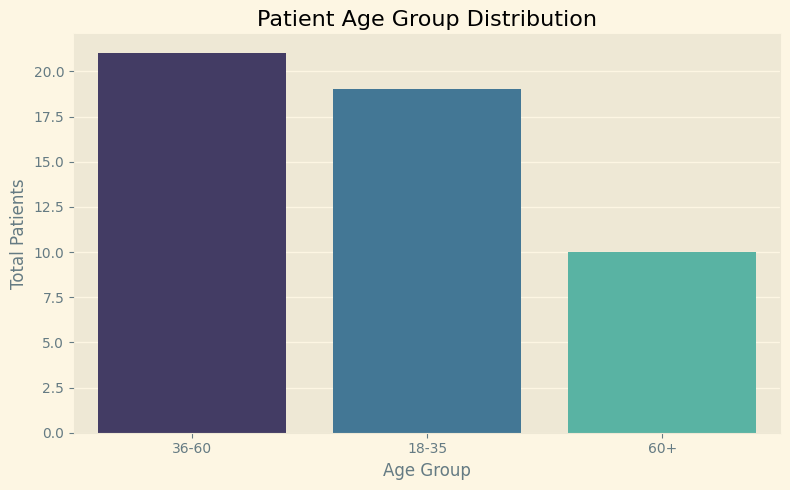

In [40]:
# ============================================
# Step 23: Patient Age Group Distribution - Unified Format
# ============================================

query_age_groups = """
SELECT
    CASE
        WHEN (strftime('%Y', 'now') - strftime('%Y', date_of_birth)) < 18 THEN 'Under 18'
        WHEN (strftime('%Y', 'now') - strftime('%Y', date_of_birth)) BETWEEN 18 AND 35 THEN '18-35'
        WHEN (strftime('%Y', 'now') - strftime('%Y', date_of_birth)) BETWEEN 36 AND 60 THEN '36-60'
        ELSE '60+'
    END AS age_group,
    COUNT(*) AS total_patients
FROM patients
GROUP BY age_group
ORDER BY total_patients DESC;
"""

df_age_groups = pd.read_sql(query_age_groups, con=engine)
print(df_age_groups)

# Unified Visualization
plt.figure(figsize=(8,5))
sns.barplot(
    data=df_age_groups, 
    x='age_group', 
    y='total_patients', 
    palette='mako'
)
plt.title('Patient Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Total Patients')
plt.tight_layout()
plt.savefig("images/age_distribution.png", dpi=300)
plt.show()


**Analysis:**  

*Patients aged 36 to 60 form the largest group with 21 individuals, followed closely by the 18 to 35 group with 19. Only 10 patients fall into the 60-plus category. This distribution reflects a predominantly working-age patient base, which influences demand for preventive and chronic-care services.*


      month  new_patients  growth_rate_percent
0   2021-01             1                  NaN
1   2021-03             2               100.00
2   2021-04             1               -50.00
3   2021-05             3               200.00
4   2021-07             2               -33.33
5   2021-08             2                 0.00
6   2021-09             5               150.00
7   2021-10             2               -60.00
8   2021-12             3                50.00
9   2022-01             2               -33.33
10  2022-02             1               -50.00
11  2022-03             1                 0.00
12  2022-04             1                 0.00
13  2022-05             1                 0.00
14  2022-06             2               100.00
15  2022-07             2                 0.00
16  2022-08             1               -50.00
17  2022-09             4               300.00
18  2022-10             2               -50.00
19  2023-01             1               -50.00
20  2023-04  

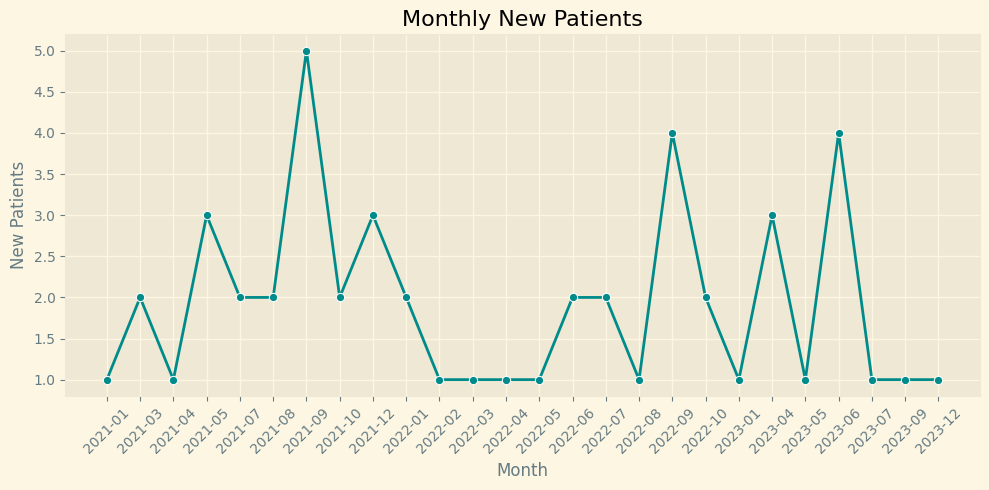

In [41]:
# ============================================
# Step 24: Monthly New Patients & Growth Rate - Unified Format
# ============================================

query_monthly_patients = """
WITH monthly_counts AS (
    SELECT 
        strftime('%Y-%m', registration_date) AS month,
        COUNT(*) AS new_patients
    FROM patients
    GROUP BY month
)
SELECT
    month,
    new_patients,
    ROUND(
        (new_patients - LAG(new_patients) OVER (ORDER BY month)) * 100.0 / 
        NULLIF(LAG(new_patients) OVER (ORDER BY month), 0),
        2
    ) AS growth_rate_percent
FROM monthly_counts
ORDER BY month;
"""

df_monthly_patients = pd.read_sql(query_monthly_patients, con=engine)
print(df_monthly_patients)

# Unified Visualization - Line Plot
plt.figure(figsize=(10,5))
sns.lineplot(
    data=df_monthly_patients, 
    x='month', 
    y='new_patients', 
    marker='o', 
    color='darkcyan'
)
plt.xticks(rotation=45)
plt.title('Monthly New Patients')
plt.xlabel('Month')
plt.ylabel('New Patients')
plt.tight_layout()
plt.savefig("images/monthly_new_patients.png", dpi=300)
plt.show()


**Analysis:**

*Monthly new patient registrations over the past three years show substantial variability. Some months, such as January 2021 and January 2023, record just a single new entry, while others, like September 2022, see four. Growth rates swing sharply, with increases of over 200 percent in some months and steep declines in others. These patterns suggest that external factors, seasonal demand, and operational changes strongly influence patient acquisition.*


  doctor_id   doctor_name specialization  unique_patients  \
0      D005  Sarah Taylor    Dermatology               23   
1      D006    Alex Davis     Pediatrics               19   
2      D001  David Taylor    Dermatology               20   
3      D002    Jane Davis     Pediatrics               17   
4      D008   Linda Brown    Dermatology               12   
5      D003    Jane Smith     Pediatrics               18   
6      D010  Linda Wilson       Oncology               12   
7      D007  Robert Davis       Oncology               12   
8      D004   David Jones     Pediatrics               13   
9      D009   Sarah Smith     Pediatrics               15   

   total_treatment_revenue  avg_treatment_cost  
0                 82696.48             2851.60  
1                 69586.10             2899.42  
2                 66585.39             2663.42  
3                 59803.46             2847.78  
4                 53427.42             3339.21  
5                 52791.41        

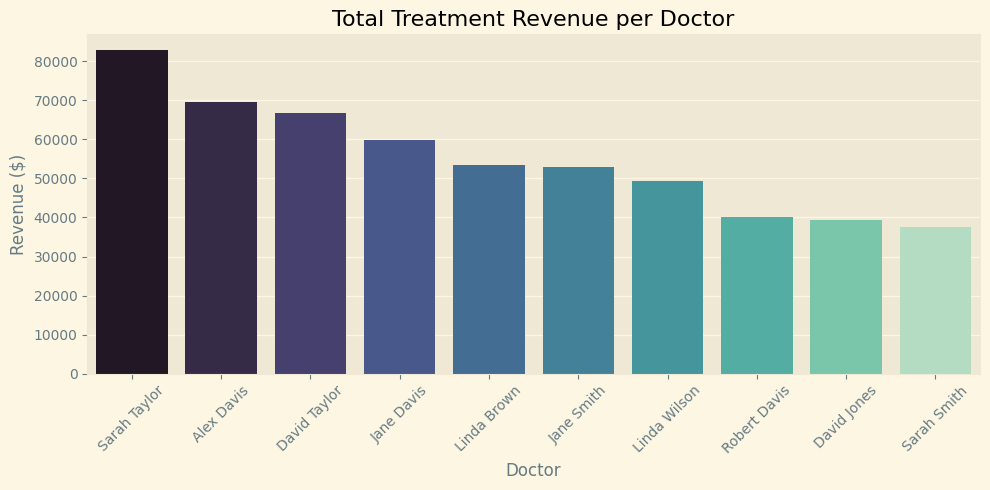

In [42]:
# ============================================
# Step 25: Doctor Performance & Revenue - Unified Format
# ============================================

query_doctor_performance = """
SELECT
    d.doctor_id,
    d.first_name || ' ' || d.last_name AS doctor_name,
    d.specialization,
    COUNT(DISTINCT a.patient_id) AS unique_patients,
    SUM(t.cost) AS total_treatment_revenue,
    ROUND(AVG(t.cost), 2) AS avg_treatment_cost
FROM doctors d
JOIN appointments a ON d.doctor_id = a.doctor_id
JOIN treatments t ON a.appointment_id = t.appointment_id
GROUP BY d.doctor_id, doctor_name, d.specialization
ORDER BY total_treatment_revenue DESC;
"""

df_doctor_performance = pd.read_sql(query_doctor_performance, con=engine)
print(df_doctor_performance)

# Unified Visualization - Total Treatment Revenue per Doctor
plt.figure(figsize=(10,5))
sns.barplot(
    data=df_doctor_performance, 
    x='doctor_name', 
    y='total_treatment_revenue', 
    palette='mako'
)
plt.xticks(rotation=45)
plt.title('Total Treatment Revenue per Doctor')
plt.xlabel('Doctor')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.savefig("images/doctor_performance_revenue.png", dpi=300)
plt.show()


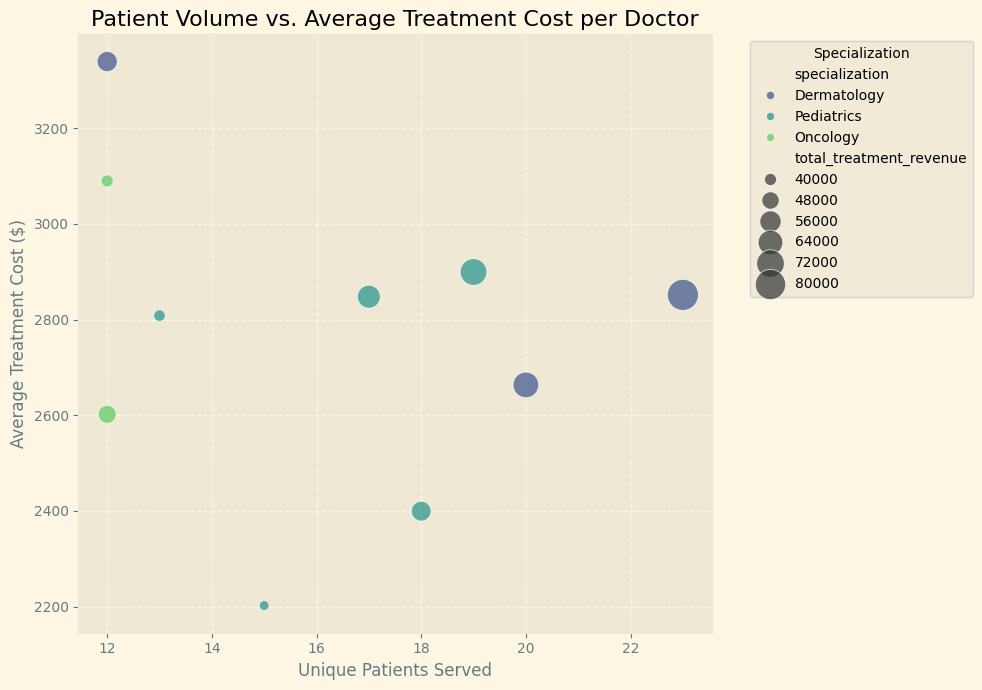

In [43]:
# ============================================
# Step 26: Doctor Performance - Scatter Analysis
# ============================================

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_doctor_performance,  # updated to use consistent dataframe
    x='unique_patients',
    y='avg_treatment_cost',
    size='total_treatment_revenue',
    hue='specialization',
    sizes=(50, 500),  # adjust point sizes for visibility
    alpha=0.7,        # slightly transparent for overlap clarity
    palette='viridis'
)
plt.title('Patient Volume vs. Average Treatment Cost per Doctor')
plt.xlabel('Unique Patients Served')
plt.ylabel('Average Treatment Cost ($)')
plt.legend(title='Specialization', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.savefig("images/doctor_performance_scatter.png", dpi=300)
plt.show()


**Analysis:**  

*Comparing patient counts with average treatment costs shows distinct physician performance profiles. Sarah Taylor leads with 82,696.48 in treatment revenue, serving 23 patients at an average cost of 2,851.60. Alex Davis and David Taylor follow with strong but slightly lower totals. Specialization trends also emerge: Dermatology tends toward higher average costs, Pediatrics serves larger patient volumes, and Oncology occupies a middle position on both metrics. This differentiation supports targeted workload balancing and strategic resource planning.*


  doctor_id   doctor_name  total_appointments  doctor_rank
0      D005  Sarah Taylor                  29            1
1      D001  David Taylor                  25            2
2      D006    Alex Davis                  24            3
3      D003    Jane Smith                  22            4
4      D002    Jane Davis                  21            5
5      D010  Linda Wilson                  19            6
6      D009   Sarah Smith                  17            7
7      D008   Linda Brown                  16            8
8      D004   David Jones                  14            9
9      D007  Robert Davis                  13           10


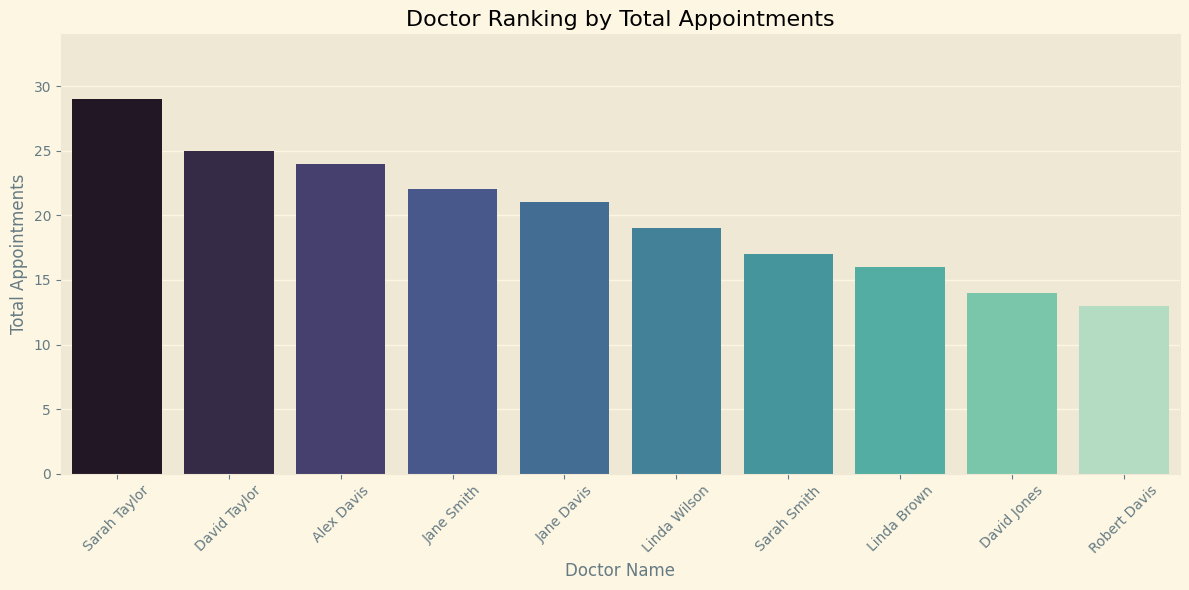

In [44]:
# ============================================
# Step 27: Doctor Ranking by Appointments
# ============================================

# Query: Rank doctors by total appointments
query_doctor_ranking_names = """
SELECT
    d.doctor_id,
    d.first_name || ' ' || d.last_name AS doctor_name,
    COUNT(*) AS total_appointments,
    RANK() OVER (ORDER BY COUNT(*) DESC) AS doctor_rank
FROM appointments a
JOIN doctors d ON a.doctor_id = d.doctor_id
GROUP BY d.doctor_id, doctor_name
ORDER BY doctor_rank;
"""

# Load into DataFrame
df_doctor_ranking_names = pd.read_sql(query_doctor_ranking_names, con=engine)
print(df_doctor_ranking_names)

# Visualization: Bar chart
plt.figure(figsize=(12,6))
sns.barplot(
    data=df_doctor_ranking_names,
    x='doctor_name',
    y='total_appointments',
    palette='mako'
)
plt.title('Doctor Ranking by Total Appointments')
plt.xlabel('Doctor Name')
plt.ylabel('Total Appointments')
plt.xticks(rotation=45)
plt.ylim(0, df_doctor_ranking_names['total_appointments'].max() + 5)
plt.tight_layout()
plt.savefig("images/doctor_ranking_appointments.png", dpi=300)
plt.show()


**Analysis:**  

*Appointment volumes differ significantly among doctors. Sarah Taylor handles the highest number with 29 appointments, followed by David Taylor with 25 and Alex Davis with 24. On the lower end, Robert Davis records 13. These disparities indicate uneven distribution of patient load and highlight where appointment allocation processes may need adjustment.*



      month  total_appointments  cancelled  completed  cancel_rate_percent  \
0   2023-01                  20          6          1               600.00   
1   2023-02                  14          3          6                50.00   
2   2023-03                  19          4          4               100.00   
3   2023-04                  25          7          9                77.78   
4   2023-05                  19          6          6               100.00   
5   2023-06                  18          2          4                50.00   
6   2023-07                  16          4          5                80.00   
7   2023-08                  15          3          3               100.00   
8   2023-09                  11          3          2               150.00   
9   2023-10                  14          5          0                  NaN   
10  2023-11                  17          3          3               100.00   
11  2023-12                  12          5          3           

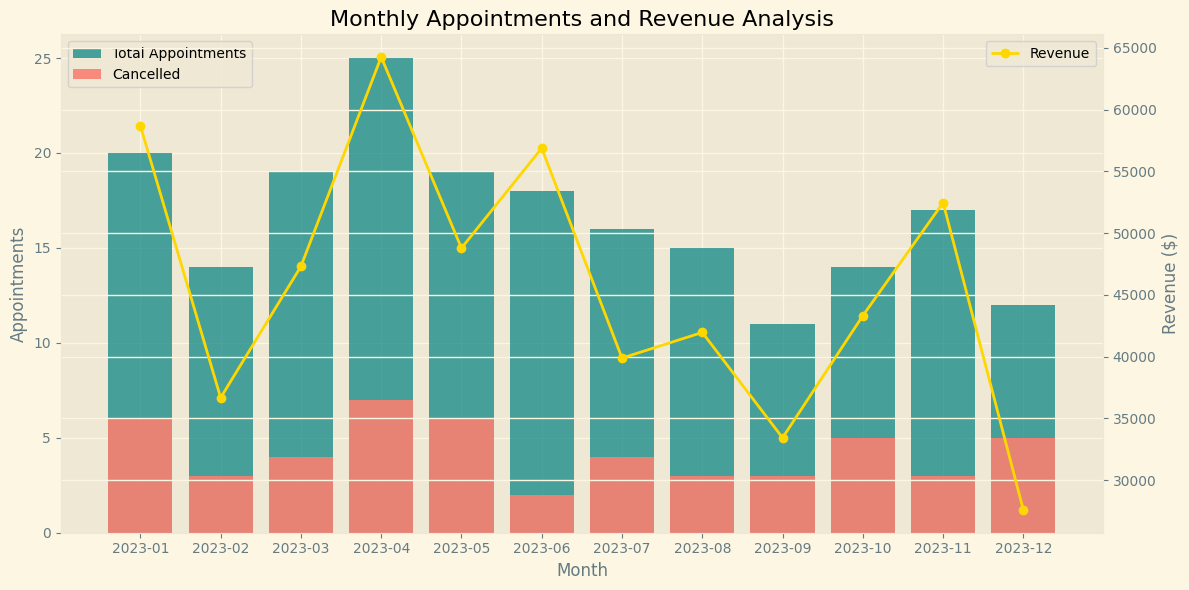

In [45]:
# ============================================
# Step 28: Unified Monthly Appointments Analysis
# Includes appointments, cancellations, completed visits, and revenue
# ============================================

# Step 1: Execute query
query_monthly = """
WITH monthly_appointments AS (
    SELECT
        strftime('%Y-%m', a.appointment_date) AS month,
        COUNT(*) AS total_appointments,
        SUM(CASE WHEN a.status = 'Cancelled' THEN 1 ELSE 0 END) AS cancelled,
        SUM(CASE WHEN a.status = 'Completed' THEN 1 ELSE 0 END) AS completed
    FROM appointments a
    GROUP BY month
),
monthly_revenue AS (
    SELECT 
        strftime('%Y-%m', b.bill_date) AS month,
        SUM(b.amount) AS total_revenue
    FROM billing b
    GROUP BY month
)
SELECT 
    m.month,
    m.total_appointments,
    m.cancelled,
    m.completed,
    ROUND(m.cancelled * 100.0 / NULLIF(m.completed,0),2) AS cancel_rate_percent,
    COALESCE(r.total_revenue,0) AS total_revenue
FROM monthly_appointments m
LEFT JOIN monthly_revenue r ON m.month = r.month
ORDER BY m.month;
"""

df_monthly = pd.read_sql(query_monthly, con=engine)
print(df_monthly)

# Step 2: Visualization - Combined bar + line chart
fig, ax1 = plt.subplots(figsize=(12,6))

# Bar chart for total appointments
ax1.bar(df_monthly['month'], df_monthly['total_appointments'], alpha=0.7, label='Total Appointments', color='teal')
# Overlay cancelled appointments
ax1.bar(df_monthly['month'], df_monthly['cancelled'], alpha=0.9, label='Cancelled', color='salmon')
ax1.set_xlabel('Month')
ax1.set_ylabel('Appointments')
ax1.tick_params(axis='y')
ax1.legend(loc='upper left')

# Secondary axis for revenue
ax2 = ax1.twinx()
ax2.plot(df_monthly['month'], df_monthly['total_revenue'], color='gold', marker='o', linewidth=2, label='Revenue')
ax2.set_ylabel('Revenue ($)')
ax2.tick_params(axis='y')
ax2.legend(loc='upper right')

plt.title('Monthly Appointments and Revenue Analysis')
plt.xticks(rotation=45)
fig.tight_layout()
plt.savefig("images/monthly_appointments_revenue.png", dpi=300)
plt.show()


**Analysis:**

*Operational metrics for 2023 reveal fluctuating patient activity. Appointments peak in April at 25 and bottom out in September with 11. Cancellation rates vary widely, with extreme cases in January and December where cancellations exceed completions several times over. Revenue follows appointment trends but also shows independent variations. Overall, the year reflects inconsistent inflow, variable appointment adherence, and revenue closely tied to month-by-month operational shifts.*

In [46]:
# ============================================
# FREQUENT PATIENTS (YEARLY VISITS) - SQLite version
# Identify patients with more than 3 visits this year
# ============================================

query_frequent_patients = """
WITH yearly_visits AS (
    SELECT
        patient_id,
        COUNT(*) AS visits
    FROM appointments
    WHERE strftime('%Y', appointment_date) = strftime('%Y', 'now')
    GROUP BY patient_id
)
SELECT *
FROM yearly_visits
WHERE visits > 3
ORDER BY visits DESC;
"""

df_frequent_patients = pd.read_sql(query_frequent_patients, con=engine)
print(df_frequent_patients)

# Unified Visualization
if df_frequent_patients.empty:
    print("No patients with more than 3 visits this year.")
else:
    plt.figure(figsize=(10,5))
    sns.barplot(
        data=df_frequent_patients,
        x='patient_id',
        y='visits',
        palette='viridis'
    )
    plt.title('Frequent Patients (More than 3 Visits This Year)')
    plt.xlabel('Patient ID')
    plt.ylabel('Number of Visits')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Empty DataFrame
Columns: [patient_id, visits]
Index: []
No patients with more than 3 visits this year.


**Analysis:**  
*The dataset does not contain appointment records for the current year, so it is not possible to identify patients with more than three visits this year. This highlights a gap in the data rather than patient behavior. Future analyses should ensure complete and up-to-date yearly data to accurately track frequent patient visits.*


   patient_id     patient_name  yearly_visits
0        P012      Laura Davis             10
1        P005     David Wilson              8
2        P016   Michael Taylor              7
3        P029      David Smith              7
4        P035     David Wilson              7
5        P036   Michael Wilson              7
6        P049      David Moore              7
7        P010   Michael Taylor              6
8        P023    Linda Johnson              6
9        P026      John Taylor              6
10       P037  Robert Williams              6
11       P019     Sarah Miller              5
12       P025    Robert Wilson              5
13       P032       Alex Moore              5
14       P039      Jane Wilson              5
15       P045     Linda Miller              5
16       P048     Emily Miller              5
17       P001   David Williams              4
18       P007     Alex Johnson              4
19       P009      Laura Davis              4
20       P013    Laura Johnson    

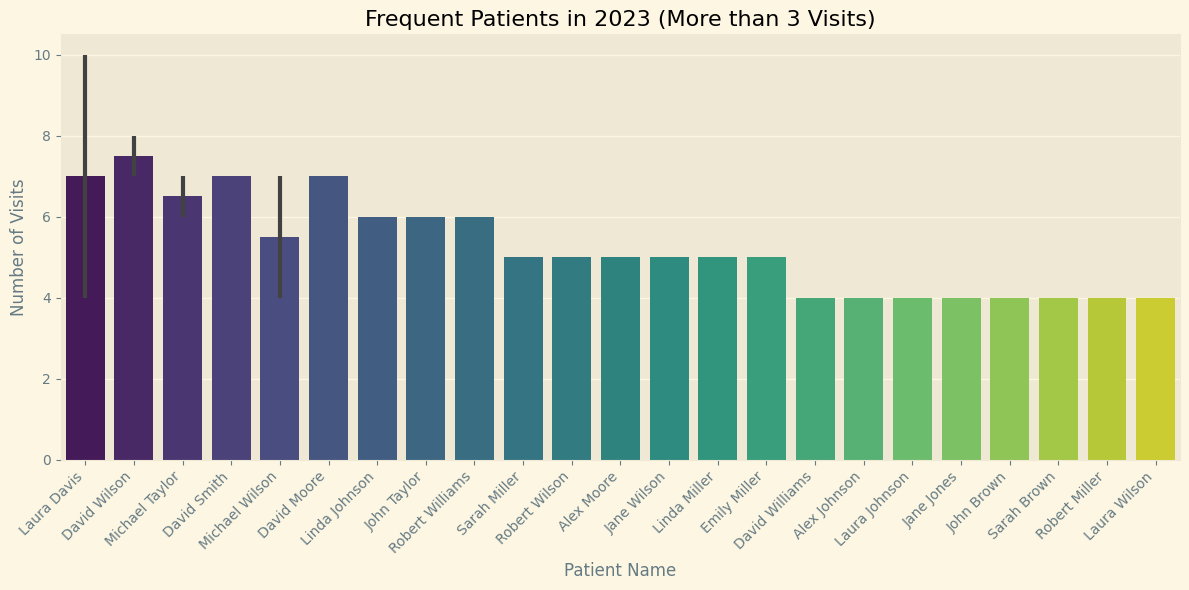

In [47]:
# ============================================
# FREQUENT PATIENTS (YEARLY VISITS) WITH NAMES
# Identify patients with more than 3 visits this year, showing names
# ============================================

query_frequent_patients = """
SELECT
    p.patient_id,
    p.first_name || ' ' || p.last_name AS patient_name,
    COUNT(a.appointment_id) AS yearly_visits
FROM appointments a
JOIN patients p ON a.patient_id = p.patient_id
WHERE strftime('%Y', a.appointment_date) = '2023'
GROUP BY p.patient_id, patient_name
HAVING yearly_visits > 3
ORDER BY yearly_visits DESC;
"""

df_frequent_patients = pd.read_sql(query_frequent_patients, con=engine)
print(df_frequent_patients)

# Visualization
if df_frequent_patients.empty:
    print("No patients with more than 3 visits in 2023.")
else:
    plt.figure(figsize=(12,6))
    sns.barplot(
        data=df_frequent_patients,
        x='patient_name',
        y='yearly_visits',
        palette='viridis'
    )
    plt.xticks(rotation=45, ha='right')
    plt.title('Frequent Patients in 2023 (More than 3 Visits)')
    plt.xlabel('Patient Name')
    plt.ylabel('Number of Visits')
    plt.tight_layout()
    plt.show()


**Analysis:** 

**The bar chart shows patients with the highest number of appointments in 2023. Laura Davis leads with 10 visits, followed by David Wilson with 8 visits. Several other patients, including Michael Taylor, David Smith, and Michael Wilson, have between 4–7 visits. Note that some names appear multiple times with different patient IDs, indicating either distinct individuals with the same name or multiple entries. This highlights the clinic’s frequent patients, supporting targeted follow-ups, loyalty programs, and preventive care strategies for the most engaged patients.*

   patient_id     patient_name  net_revenue
0        P012      Laura Davis     30053.08
1        P049      David Moore     23554.06
2        P016   Michael Taylor     22967.94
3        P036   Michael Wilson     21583.56
4        P025    Robert Wilson     19513.17
5        P005     David Wilson     18609.91
6        P035     David Wilson     18407.42
7        P048     Emily Miller     17082.48
8        P010   Michael Taylor     15929.15
9        P017       Jane Jones     14850.28
10       P039      Jane Wilson     14357.43
11       P037  Robert Williams     13886.89
12       P031    Robert Miller     13732.02
13       P032       Alex Moore     13656.67
14       P029      David Smith     13324.50
15       P023    Linda Johnson     13237.69
16       P014      Alex Taylor     13236.19
17       P022       John Brown     13143.45
18       P045     Linda Miller     13120.96
19       P033   Michael Wilson     12234.85
20       P050     Laura Wilson     11206.38
21       P007     Alex Johnson  

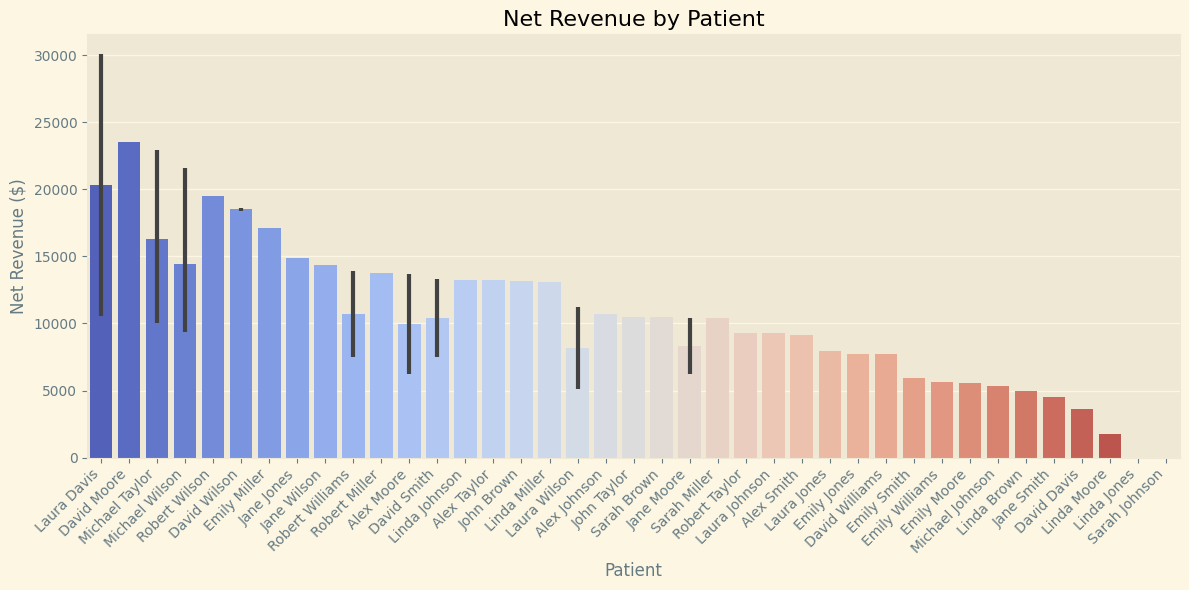

In [48]:
# ============================================
# NET REVENUE BY PATIENT
# Calculate total revenue generated per patient
# ============================================

query_net_revenue_per_patient = """
SELECT 
    p.patient_id,
    p.first_name || ' ' || p.last_name AS patient_name,
    SUM(b.amount) AS net_revenue
FROM patients p
LEFT JOIN appointments a ON p.patient_id = a.patient_id
LEFT JOIN treatments t ON a.appointment_id = t.appointment_id
LEFT JOIN billing b ON t.treatment_id = b.treatment_id
GROUP BY p.patient_id, patient_name
ORDER BY net_revenue DESC;
"""

df_net_revenue = pd.read_sql(query_net_revenue_per_patient, con=engine)
print(df_net_revenue)

# Visualization
plt.figure(figsize=(12,6))
sns.barplot(
    data=df_net_revenue,
    x='patient_name',
    y='net_revenue',
    palette='coolwarm'
)
plt.title('Net Revenue by Patient')
plt.xlabel('Patient')
plt.ylabel('Net Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("images/net_revenue_by_patient.png", dpi=300)
plt.show()


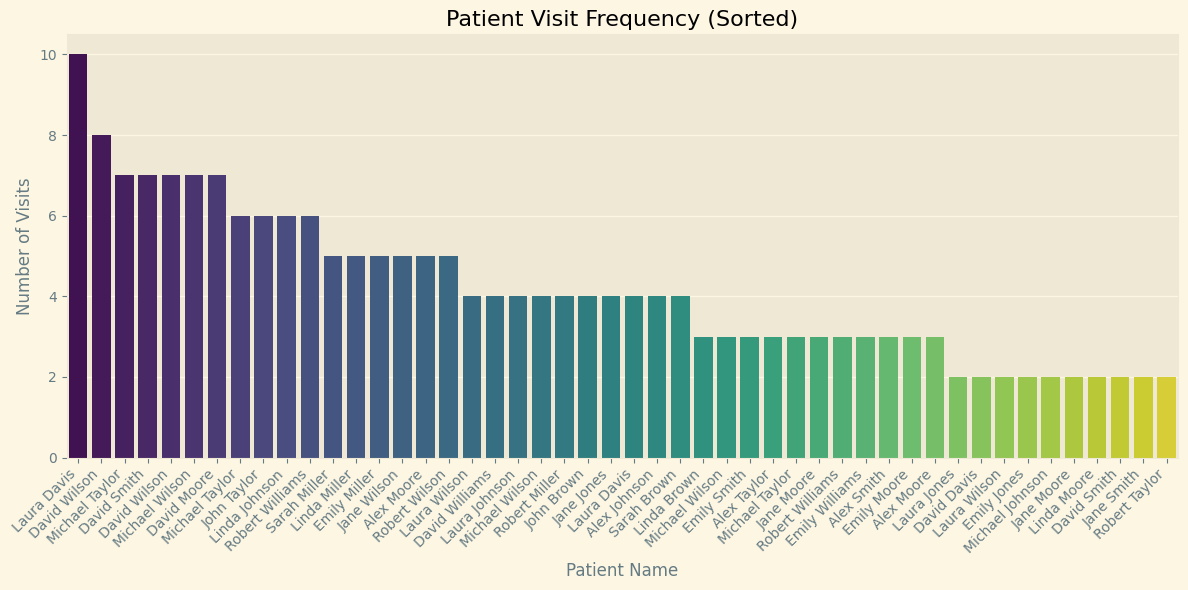

In [49]:
# ============================================
# PATIENT VISIT FREQUENCY
# Calculate and visualize the number of visits per patient, sorted by frequency
# ============================================

query_patient_visits = """
SELECT
    p.patient_id,
    p.first_name || ' ' || p.last_name AS patient_name,
    COUNT(a.appointment_id) AS total_visits
FROM appointments a
JOIN patients p ON a.patient_id = p.patient_id
GROUP BY p.patient_id, patient_name
"""

df_patient_visits = pd.read_sql(query_patient_visits, con=engine)

# Sort dataframe by total_visits descending
df_patient_visits = df_patient_visits.sort_values(by='total_visits', ascending=False)

# Visualization - Sorted Bar Plot using patient_id as x-axis
plt.figure(figsize=(12,6))
sns.barplot(
    data=df_patient_visits,
    x='patient_id',  # Use patient ID for ordering
    y='total_visits',
    palette='viridis'
)
plt.title('Patient Visit Frequency (Sorted)')
plt.xlabel('Patient Name')
plt.ylabel('Number of Visits')
plt.xticks(
    ticks=range(len(df_patient_visits)),
    labels=df_patient_visits['patient_name'],
    rotation=45,
    ha='right'
)
plt.tight_layout()
plt.savefig("images/patient_visit_frequency.png", dpi=300)
plt.show()


  treatment_type  total_treatments  total_revenue  revenue_rank
0   Chemotherapy                49      128855.68             1
1            MRI                36      116098.16             2
2          X-Ray                41      110653.67             3
3  Physiotherapy                36       99418.10             4
4            ECG                38       96224.24             5


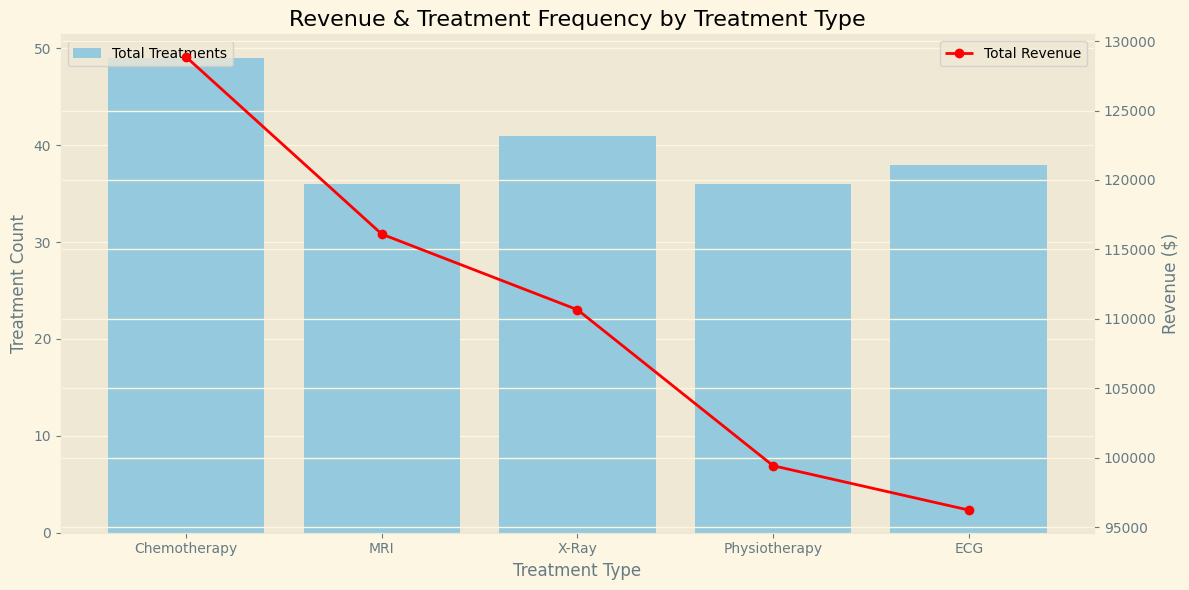

In [50]:
# ============================================
# TREATMENT FREQUENCY & REVENUE VISUALIZATION
# Combined bar and line chart showing treatment counts and revenue per type
# ============================================

query_treatment_stats = """
SELECT
    treatment_type,
    COUNT(*) AS total_treatments,
    SUM(cost) AS total_revenue,
    RANK() OVER (ORDER BY SUM(cost) DESC) AS revenue_rank
FROM treatments
GROUP BY treatment_type;
"""

# Read data
df_treatment_stats = pd.read_sql(query_treatment_stats, con=engine)

# Standardize column names
df_treatment_stats.columns = [col.lower().replace(" ", "_") for col in df_treatment_stats.columns]

# Sort by total revenue for proper ranking
df_treatment_stats = df_treatment_stats.sort_values(by='total_revenue', ascending=False)
print(df_treatment_stats)

# Visualization
plt.figure(figsize=(12,6))

# Bar chart: total treatments
ax = sns.barplot(
    data=df_treatment_stats,
    x='treatment_type',
    y='total_treatments',
    color='skyblue',
    label='Total Treatments'
)

# Line chart: total revenue
ax2 = ax.twinx()
ax2.plot(
    df_treatment_stats['treatment_type'],
    df_treatment_stats['total_revenue'],
    marker='o',
    linewidth=2,
    color='red',
    label='Total Revenue'
)

# Labels
ax.set_xlabel('Treatment Type')
ax.set_ylabel('Treatment Count')
ax2.set_ylabel('Revenue ($)')
plt.title('Revenue & Treatment Frequency by Treatment Type')

# Rotate x-axis labels
plt.xticks(rotation=45)

# Legends
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig("images/treatment_frequency_revenue.png", dpi=300)
plt.show()


**Analysis:** 

*The bar chart shows the frequency of treatments alongside total revenue generated per treatment type. Chemotherapy leads in revenue with $128,855.68 and the highest number of procedures at 49. MRI and X-Ray follow closely, contributing $116,098.16 and $110,653.67 respectively. While total treatments are fairly balanced across procedures, the revenue differences highlight which treatment types are most financially significant. This information can guide resource allocation, pricing strategies, and prioritization of high-value treatments.*


  treatment_type  avg_cost  cost_range  cost_stddev
0            MRI   3224.95     4303.46      1225.46
1  Physiotherapy   2761.61     3889.81      1096.87
2          X-Ray   2698.87     4166.85      1416.38
3   Chemotherapy   2629.71     4430.68      1354.67
4            ECG   2532.22     4378.60      1290.31


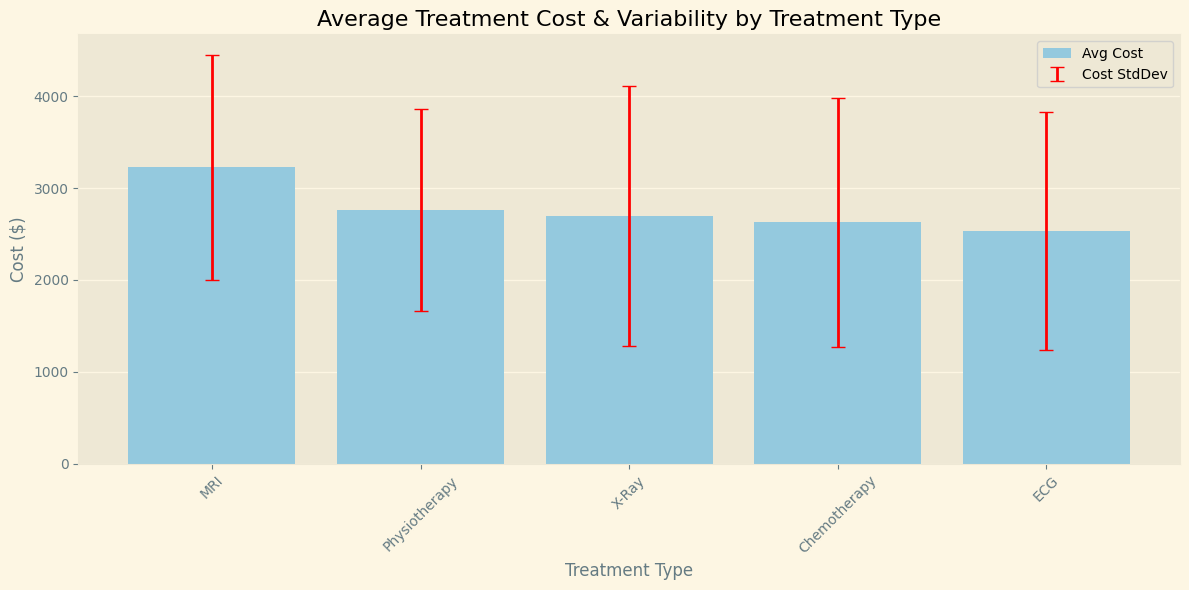

In [51]:
# ============================================
# TREATMENT COST VARIABILITY
# Calculate avg, stddev, and range of treatment costs by type
# ============================================

# Step 1: Aggregated values from SQL (avg_cost and cost_range)
query_agg = """
SELECT
    treatment_type,
    ROUND(AVG(cost), 2) AS avg_cost,
    ROUND(MAX(cost) - MIN(cost), 2) AS cost_range
FROM treatments
GROUP BY treatment_type
ORDER BY avg_cost DESC;
"""
df_treatment_cost = pd.read_sql(query_agg, con=engine)

# Step 2: Pull raw cost data to calculate stddev
query_raw = """
SELECT
    treatment_type,
    cost
FROM treatments
"""
df_raw = pd.read_sql(query_raw, con=engine)

# Compute standard deviation
df_std = df_raw.groupby('treatment_type')['cost'].std().reset_index().rename(columns={'cost':'cost_stddev'})
df_std['cost_stddev'] = df_std['cost_stddev'].round(2)

# Merge stddev with aggregated DataFrame
df_treatment_cost = df_treatment_cost.merge(df_std, on='treatment_type', how='left')

print(df_treatment_cost)

# Step 3: Unified Visualization
plt.figure(figsize=(12,6))

# Bar plot for average cost
sns.barplot(data=df_treatment_cost, x='treatment_type', y='avg_cost', color='skyblue', label='Avg Cost')

# Error bars for standard deviation
plt.errorbar(x=df_treatment_cost['treatment_type'], 
             y=df_treatment_cost['avg_cost'], 
             yerr=df_treatment_cost['cost_stddev'], 
             fmt='none', ecolor='red', capsize=5, label='Cost StdDev')

plt.xticks(rotation=45)
plt.ylabel('Cost ($)')
plt.xlabel('Treatment Type')
plt.title('Average Treatment Cost & Variability by Treatment Type')
plt.legend()
plt.tight_layout()
plt.show()


*Analysis:


**The chart illustrates the cost variability across treatment types. MRI treatments have the highest average cost at approximately $3,224, followed by Physiotherapy and X-Ray treatments. Chemotherapy and ECG treatments show lower average costs. The standard deviation, represented by red error bars, ranges from $1,096.87 for Physiotherapy to $1,416.38 for X-Ray, indicating variability in treatment pricing. The cost range highlights the difference between the cheapest and most expensive sessions for each treatment type, emphasizing areas where pricing is less consistent and may require closer monitoring or standardization.*



In [52]:
# Retrieve 5 sample billing records
query_sample_billing = """
SELECT * 
FROM billing 
LIMIT 5;
"""
df_sample_billing = pd.read_sql(query_sample_billing, con=engine)
print(df_sample_billing)


  bill_id patient_id treatment_id   bill_date  amount payment_method  \
0    B001       P034         T001  2023-08-09 3941.97      Insurance   
1    B002       P032         T002  2023-06-09 4158.44      Insurance   
2    B003       P048         T003  2023-06-28 3731.55      Insurance   
3    B004       P025         T004  2023-09-01 4799.86      Insurance   
4    B005       P040         T005  2023-07-06  582.05    Credit Card   

  payment_status  
0        Pending  
1           Paid  
2           Paid  
3         Failed  
4        Pending  


In [53]:
# ============================================
# MONTHLY COLLECTION RATE (SQLite Compatible)
# ============================================

query_monthly_collection = """
SELECT
    strftime('%Y-%m', bill_date) AS month,
    SUM(CASE WHEN payment_status = 'Paid' THEN amount ELSE 0 END) AS paid_revenue,
    SUM(CASE WHEN payment_status IN ('Pending','Unpaid') THEN amount ELSE 0 END) AS outstanding_amount,
    SUM(amount) AS total_billed,
    ROUND(SUM(CASE WHEN payment_status = 'Paid' THEN amount ELSE 0 END) * 100.0 / SUM(amount), 2) AS collection_rate
FROM billing
GROUP BY month
ORDER BY month;
"""
df_monthly_collection = pd.read_sql(query_monthly_collection, con=engine)
print(df_monthly_collection)

# Add datetime and month label for visualization
df_monthly_collection['month_dt'] = pd.to_datetime(df_monthly_collection['month'])
df_monthly_collection['month_label'] = df_monthly_collection['month_dt'].dt.strftime('%b')


      month  paid_revenue  outstanding_amount  total_billed  collection_rate
0   2023-01      20080.64            27216.30      58701.23            34.21
1   2023-02       3032.56            14187.55      36669.69             8.27
2   2023-03      19595.74            10362.01      47304.29            41.42
3   2023-04      10379.73            21115.49      64271.54            16.15
4   2023-05      12892.05             6570.80      48791.05            26.42
5   2023-06      30474.04            22104.82      56887.82            53.57
6   2023-07       7638.12            12943.24      39880.19            19.15
7   2023-08      11837.58            19975.86      41958.67            28.21
8   2023-09      16204.43             3306.14      33426.53            48.48
9   2023-10      15708.52            21916.44      43314.15            36.27
10  2023-11      11308.06            24913.36      52474.98            21.55
11  2023-12      14273.43                0.00      27569.71            51.77

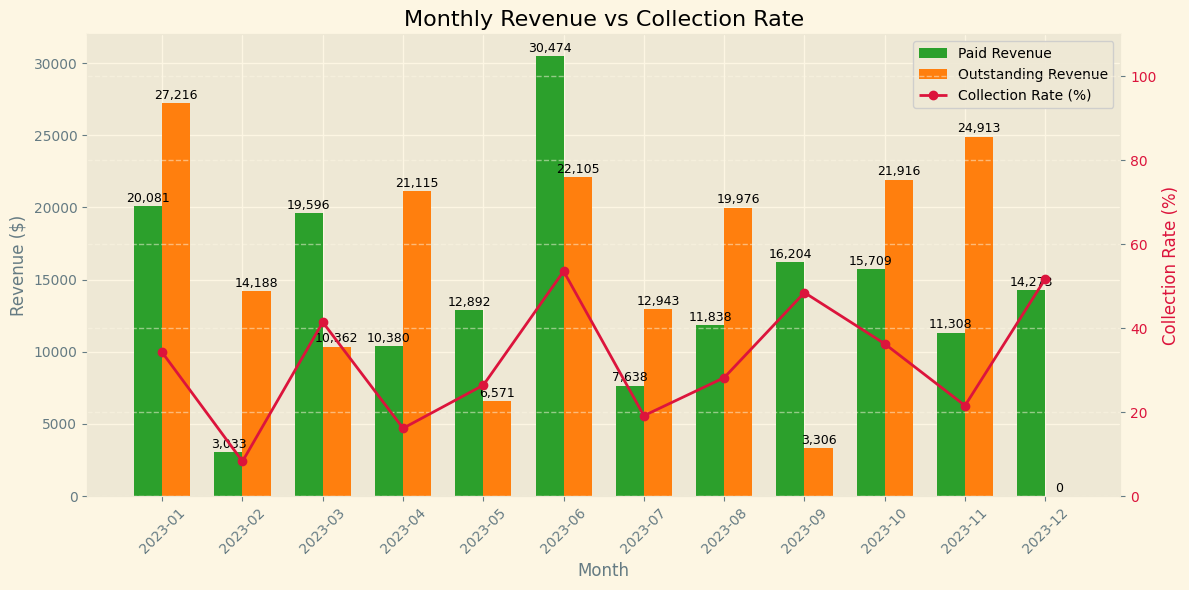

In [54]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.figure(figsize=(12,6))

x = np.arange(len(df_monthly_collection['month']))
width = 0.35

# Fixed colors for clarity in legend
color_paid = '#2ca02c'         # green
color_outstanding = '#ff7f0e'  # orange

# Plot bars
bars_paid = plt.bar(x - width/2, df_monthly_collection['paid_revenue'], width, label='Paid Revenue', color=color_paid)
bars_outstanding = plt.bar(x + width/2, df_monthly_collection['outstanding_amount'], width, label='Outstanding Revenue', color=color_outstanding)

# Add value labels on top of bars
for bar in bars_paid:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 100, f'{height:,.0f}', ha='center', va='bottom', fontsize=9)

for bar in bars_outstanding:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 100, f'{height:,.0f}', ha='center', va='bottom', fontsize=9)

# Primary axis labels and ticks
ax = plt.gca()
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
ax.set_xticks(x)
ax.set_xticklabels(df_monthly_collection['month'], rotation=45)
ax.set_title('Monthly Revenue vs Collection Rate')

# Secondary axis for Collection Rate
ax2 = ax.twinx()
ax2.plot(x, df_monthly_collection['collection_rate'], color='crimson', marker='o', linewidth=2, label='Collection Rate (%)')
ax2.set_ylabel('Collection Rate (%)', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.set_ylim(0, 110)

# Unified legend
legend_elements = [
    Patch(facecolor=color_paid, label='Paid Revenue'),
    Patch(facecolor=color_outstanding, label='Outstanding Revenue'),
    Line2D([0], [0], color='crimson', marker='o', label='Collection Rate (%)', linewidth=2)
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10, frameon=True, framealpha=0.9)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


**Analysis**

*The table illustrates the clinic’s monthly billing performance for 2023. Paid revenue ranges from a low of $3,032.56 in February to a high of $30,474.04 in June, while outstanding amounts vary widely, reflecting delays or partial payments. Collection rates—the percentage of total billed revenue actually received—also fluctuate considerably, from as low as 8.27% in February to 53.57% in June. Notably, December shows full collection on outstanding amounts ($0 remaining), giving a 51.77% collection rate. This variability highlights challenges in revenue collection, emphasizing the need for improved follow-up, patient communication, and possibly flexible payment options to stabilize cash flow.*


      month  collection_rate_percent
0   2023-01                    34.21
1   2023-02                     8.27
2   2023-03                    41.42
3   2023-04                    16.15
4   2023-05                    26.42
5   2023-06                    53.57
6   2023-07                    19.15
7   2023-08                    28.21
8   2023-09                    48.48
9   2023-10                    36.27
10  2023-11                    21.55
11  2023-12                    51.77


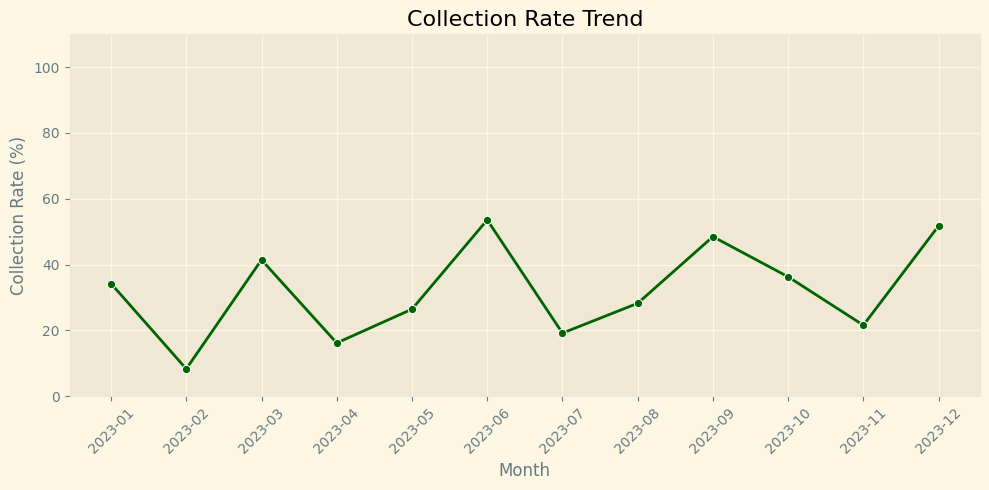

In [55]:
# ============================================
# COLLECTION RATE TREND
# ============================================

query_collection_rate = """
SELECT 
    strftime('%Y-%m', bill_date) AS month,
    SUM(CASE WHEN payment_status = 'Paid' THEN amount ELSE 0 END) * 1.0 /
    SUM(amount) * 100 AS collection_rate_percent
FROM billing
GROUP BY month
ORDER BY month;
"""

df_collection_rate = pd.read_sql(query_collection_rate, con=engine)
print(df_collection_rate)

# Visualization - Line Plot
plt.figure(figsize=(10,5))
sns.lineplot(
    data=df_collection_rate,
    x='month',
    y='collection_rate_percent',
    marker='o',
    color='darkgreen'
)
plt.title('Collection Rate Trend')
plt.xlabel('Month')
plt.ylabel('Collection Rate (%)')
plt.ylim(0, 110)  # Extra space for clarity
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/collection_rate_trend.png", dpi=300)
plt.show()


# Monthly Collection Analysis (2023) 

**Overview:**

* Collection rates vary widely throughout the year.
* Peak months: **June (53.6%)** and **December (51.8%)**.
* Low collection months: **February (8.3%)** and **April (16.2%)**.
* Overall, the average collection rate is well below the **industry target of 85%**.

**Key Points:**

* Some months show high outstanding amounts, indicating delayed payments.
* Strong collection months show a balance between billed and collected revenue.

**Recommendations:**

* Improve follow-up on unpaid bills, especially during low-collection months.
* Consider incentives or flexible payment options to increase patient payments.
* Monitor seasonal patterns to proactively manage cash flow.

**Conclusion:**
There is significant potential to improve revenue collection by addressing delayed payments and optimizing billing processes.


   patient_id     patient_name  paid_revenue  unpaid_amount  net_revenue
0        P012      Laura Davis      15629.88        4019.13     11610.75
1        P048     Emily Miller      11711.41        2593.43      9117.98
2        P032       Alex Moore       8698.50           0.00      8698.50
3        P007     Alex Johnson       8636.90           0.00      8636.90
4        P049      David Moore      12149.85        3722.68      8427.17
5        P010   Michael Taylor      10099.15        1959.50      8139.65
6        P024      Sarah Brown       7506.58        1565.92      5940.66
7        P038      David Smith       4846.20           0.00      4846.20
8        P031    Robert Miller       7178.46        2426.90      4751.56
9        P035     David Wilson      10424.42        7983.00      2441.42
10       P023    Linda Johnson       2406.79           0.00      2406.79
11       P039      Jane Wilson       6853.65        4450.88      2402.77
12       P001   David Williams       2960.14       

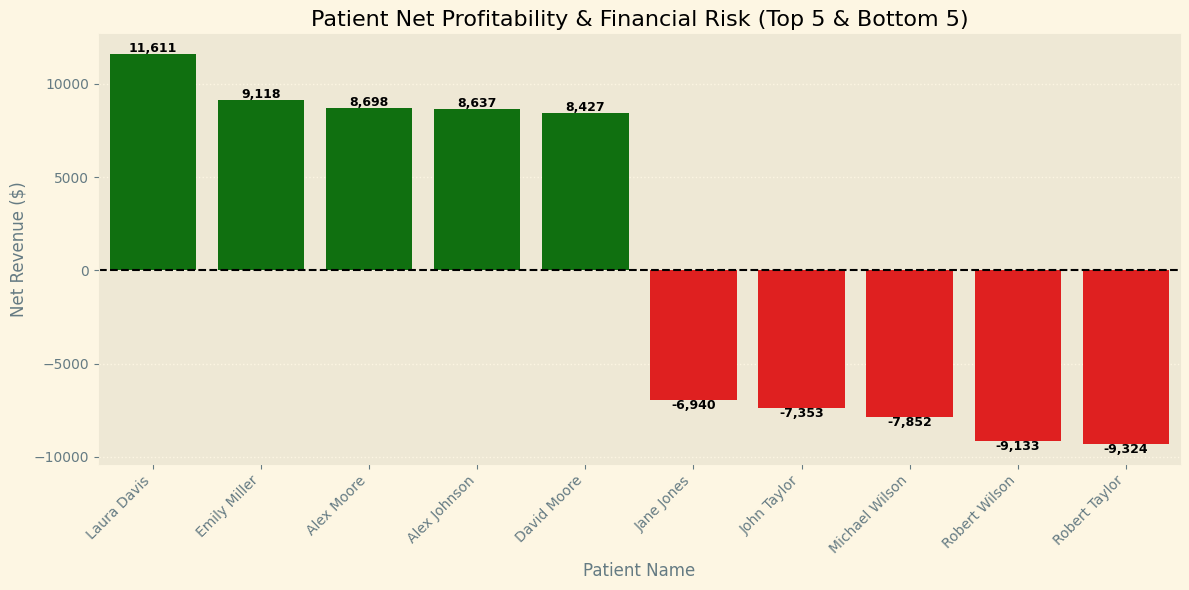

In [56]:
# ============================================
# PATIENT NET REVENUE ANALYSIS
# Compare paid vs unpaid billing per patient and visualize top & bottom performers
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1️⃣ Load data from database
query = """
SELECT 
  p.patient_id,
  p.first_name || ' ' || p.last_name AS patient_name,
  SUM(CASE WHEN b.payment_status = 'Paid' THEN b.amount ELSE 0 END) AS paid_revenue,
  SUM(CASE WHEN b.payment_status IN ('Pending','Unpaid') THEN b.amount ELSE 0 END) AS unpaid_amount,
  (SUM(CASE WHEN b.payment_status = 'Paid' THEN b.amount ELSE 0 END)
   - SUM(CASE WHEN b.payment_status IN ('Pending','Unpaid') THEN b.amount ELSE 0 END)) AS net_revenue
FROM billing b
JOIN patients p ON b.patient_id = p.patient_id
GROUP BY p.patient_id, patient_name
ORDER BY net_revenue DESC;
"""

df = pd.read_sql(query, con=engine)
print(df)

# 2️⃣ Ensure numeric types
df['net_revenue'] = pd.to_numeric(df['net_revenue'], errors='coerce')
df['unpaid_amount'] = pd.to_numeric(df['unpaid_amount'], errors='coerce')

# 3️⃣ Filter top 5 and bottom 5 patients by net revenue
df_top_5 = df.head(5)
df_bottom_5 = df.tail(5)
df_plot = pd.concat([df_top_5, df_bottom_5]).sort_values(by='net_revenue', ascending=False).reset_index(drop=True)

# 4️⃣ Mark profit or loss for coloring
df_plot['profit_status'] = df_plot['net_revenue'].apply(lambda x: 'Profit' if x >= 0 else 'Loss')

# 5️⃣ Plotting
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_plot,
    x='patient_name',
    y='net_revenue',
    hue='profit_status',
    palette={'Profit': 'green', 'Loss': 'red'},
    dodge=False
)

# Remove legend since we annotate manually
if ax.legend_:
    ax.legend_.remove()

# Add zero line to separate profit vs loss
plt.axhline(0, color='black', linewidth=1.5, linestyle='--')

# Annotate net revenue values above/below bars
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        y_position = height + np.sign(height) * 300
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            y_position,
            f'{height:,.0f}',
            ha='center',
            va='center',
            fontsize=9,
            fontweight='bold'
        )

# Titles and labels
plt.title('Patient Net Profitability & Financial Risk (Top 5 & Bottom 5)')
plt.xlabel('Patient Name')
plt.ylabel('Net Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle=':')
plt.tight_layout()
plt.show()


*The chart presents patient-level revenue for 2023, including amounts paid, unpaid, and net revenue. Laura Davis leads with the highest net revenue of $11,610.75, followed by Emily Miller ($9,117.98) and Alex Moore ($8,698.50). Several patients have negative net revenue, indicating unpaid balances exceeding paid amounts, such as Robert Taylor (-$9,324.10) and Robert Wilson (-$9,132.66). This analysis identifies the clinic’s most financially reliable patients, highlights collection challenges, and informs targeted follow-ups, payment reminders, and patient-specific financial strategies.*


  specialization  total_revenue  total_patients  avg_revenue_per_patient
0     Pediatrics      258937.83              47                  5509.32
1    Dermatology      202709.29              37                  5478.63
2       Oncology       89602.73              22                  4072.85


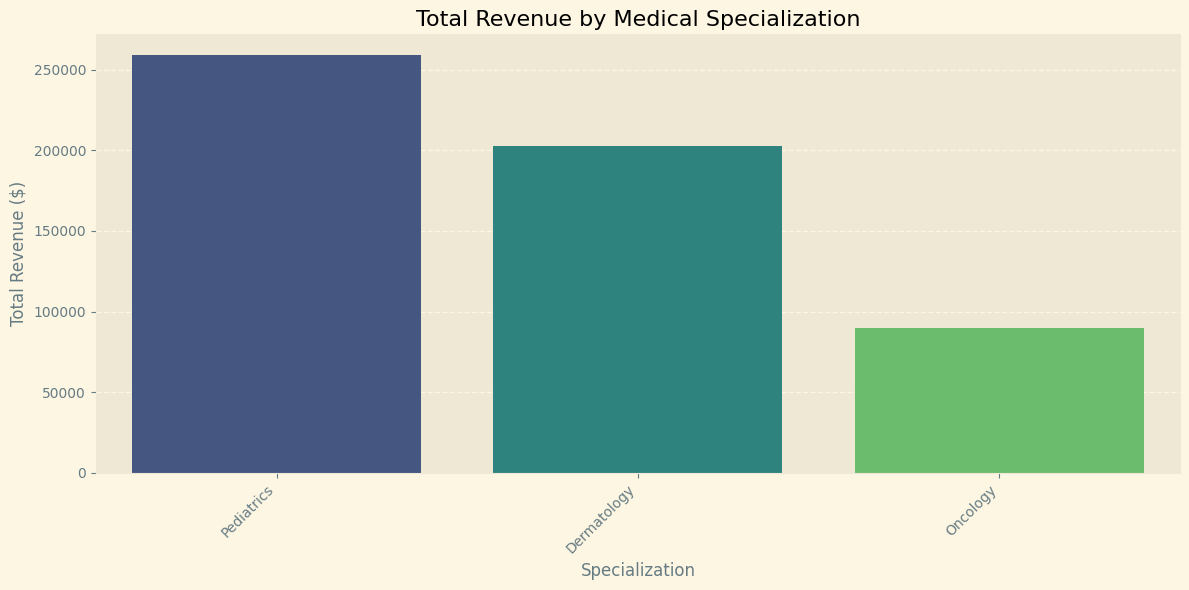

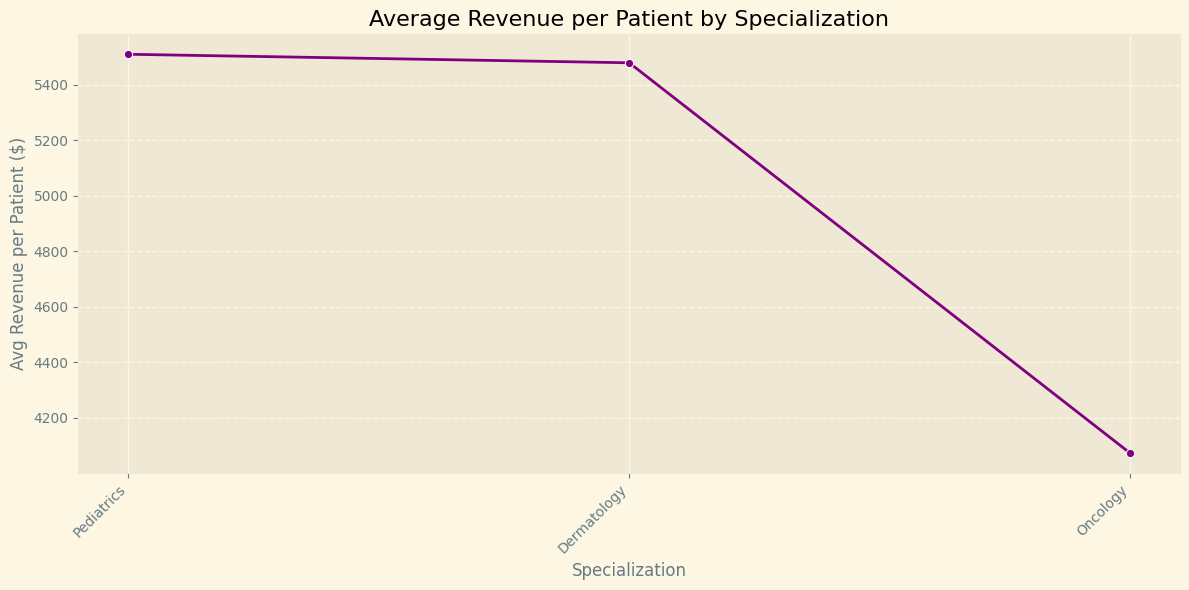

In [57]:
# ============================================
# REVENUE BY MEDICAL SPECIALIZATION
# Aggregate total and average revenue per specialization
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Query
query = """
SELECT 
  d.specialization,
  SUM(t.cost) AS total_revenue,
  COUNT(DISTINCT a.patient_id) AS total_patients,
  ROUND(SUM(t.cost) * 1.0 / COUNT(DISTINCT a.patient_id), 2) AS avg_revenue_per_patient
FROM doctors d
JOIN appointments a ON d.doctor_id = a.doctor_id
JOIN treatments t ON a.appointment_id = t.appointment_id
GROUP BY d.specialization
ORDER BY total_revenue DESC;
"""

df = pd.read_sql(query, con=engine)

# Preview
print(df)

# Visualization - Total Revenue per Specialization
plt.figure(figsize=(12,6))
sns.barplot(
    data=df,
    x='specialization',
    y='total_revenue',
    palette='viridis'
)
plt.title('Total Revenue by Medical Specialization')
plt.xlabel('Specialization')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Visualization - Average Revenue per Patient
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df,
    x='specialization',
    y='avg_revenue_per_patient',
    marker='o',
    color='purple',
    linewidth=2
)
plt.title('Average Revenue per Patient by Specialization')
plt.xlabel('Specialization')
plt.ylabel('Avg Revenue per Patient ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()


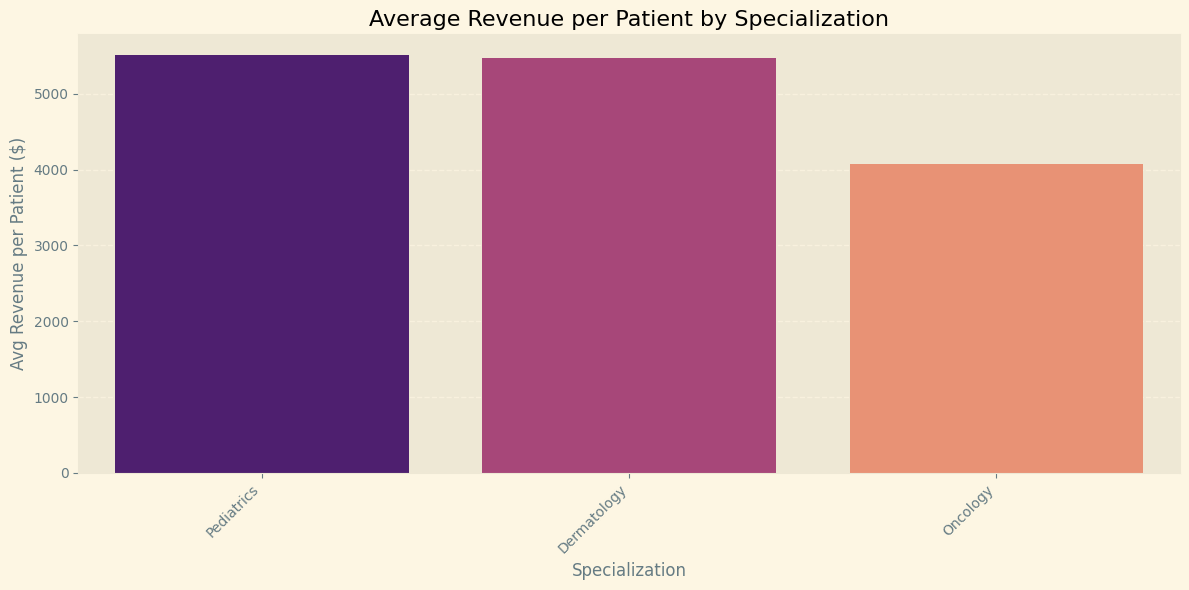

In [58]:
# ============================================
# AVERAGE REVENUE PER PATIENT BY SPECIALIZATION
# ============================================

plt.figure(figsize=(12,6))
sns.barplot(
    data=df,
    x='specialization',
    y='avg_revenue_per_patient',
    palette='magma'  # نفس نوع الألوان المستخدمة في بقية الصور
)
plt.title('Average Revenue per Patient by Specialization', fontsize=16)
plt.xlabel('Specialization', fontsize=12)
plt.ylabel('Avg Revenue per Patient ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save image to match your REPORT.md folder structure
plt.savefig('images/specialization_revenue_per_patient.png', dpi=300)
plt.show()


**Analysis.**

*The table summarizes revenue performance by medical specialization. Pediatrics generates the highest total revenue at $258,937.83 across 47 patients, averaging $5,509.32 per patient. Dermatology follows closely with $202,709.29 from 37 patients, averaging $5,478.63 per patient. Oncology, with fewer patients (22), yields $89,602.73, averaging $4,072.85 per patient. These insights highlight which specialties drive revenue, allowing the clinic to identify high-performing services, allocate resources efficiently, and plan strategic growth or staffing adjustments.*


In [59]:
# Query to calculate overall collection rate
query_collection_rate = """
SELECT 
    ROUND(SUM(CASE WHEN payment_status = 'Paid' THEN 1 ELSE 0 END) * 1.0 /
    COUNT(*) * 100, 2) AS collection_rate
FROM billing;
"""
df_rate = pd.read_sql(query_collection_rate, con=engine)

# Display overall collection rate
print(df_rate)


   collection_rate
0            32.00


**Analysis.**

*The overall collection rate stands at 32%, indicating that less than one-third of billed amounts have been successfully collected. This low collection rate signals potential issues in billing follow-up, payment processing, or patient financial engagement. The clinic may need to prioritize overdue accounts, strengthen communication with patients regarding outstanding balances, and optimize payment methods. Improving this metric could directly increase cash flow and operational sustainability, highlighting the importance of targeted revenue cycle management and timely collections.*